# Network Flow Duration Prediction: Comprehensive Regression Analysis
## Machine Learning Capstone Project - Regression Track

### Problem Formulation
In modern cybersecurity and network traffic engineering, understanding and predicting network flow duration (`flow_duration`) is crucial for adaptive bandwidth throttling, detecting stealthy command-and-control (C2) beaconing, spotting Slowloris denial-of-service attacks, and optimizing stateful firewall connection tables. A network flow is a sequence of packets exchanged between a source and destination IP and port using a specific transport protocol.

### Capstone Objectives & Methodological Rigor
1. **Full-Data Evaluation:** Train and rigorously evaluate all **10 required regression algorithms** on the complete, un-subsampled training dataset (94,337 training rows).
2. **Leakage-Free Feature Engineering:** Construct valid volumetric predictors (`total_packets`) while strictly purging timing features (`*iat*`), active/idle durations, and flow rate variables that mechanically encode the target.
3. **Target Distribution Investigation on Training Data:** Characterize extreme target skewness (skewness: 121.03, kurtosis: 16,077.00) and empirically evaluate `log1p` target transformation vs. raw-scale modeling strictly via 5-fold cross-validation on training data (zero test-set contamination).
4. **Strict Isolation of the Held-Out Test Set:** All exploratory parameter checks and target transformation decisions are conducted on the training set only. The 23,585 held-out test rows are evaluated strictly once for each baseline and tuned model.
5. **Stratified 5-Fold Cross-Validation:** Because the continuous target is extraordinarily skewed, we implement genuine quantile-binned `StratifiedKFold` on the training set to ensure that each fold has a similar representation of the target distribution, including short, medium, and long-duration flows.
6. **Consistent Diagnostic Analyses:** Residual analysis and Predicted-vs-Actual evaluations are primarily attached to the **Decision Tree Regressor** (the top-performing model on the held-out test set), with comparative diagnostics provided for **Random Forest** (the top cross-validation ensemble). Tree-based feature importance is extracted from the Random Forest ensemble using strictly non-causal language.

### 10 Evaluated Algorithms
1. Linear Regression (Baseline Ordinary Least Squares)
2. Ridge Regression ($L_2$ Regularization)
3. Lasso Regression ($L_1$ Sparsity Regularization)
4. ElasticNet Regression (Combined $L_1/L_2$ Regularization)
5. Polynomial Regression (Degree 2 & 3 Nonlinear Expansions on Domain Features)
6. Decision Tree Regressor (Nonlinear Recursive Partitioning)
7. Random Forest Regressor (Bagging Ensemble of Decorrelated Trees)
8. Gradient Boosting Regressor (Sequential Gradient-Descent Boosting)
9. Support Vector Regression (SVR - Linear Margin Maximization on Full Data)
10. K-Nearest Neighbors Regressor (KNN - Instance-Based Distance Metric Regression)


## 1. Environment Setup and Dataset Loading

We load the cleaned RT_IOT2022 dataset and configure the scientific computing environment.


In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Linear & Regularized Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# Tree & Ensemble Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# Kernel & Distance Models
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Configure visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11

# Robust file path resolution
data_path = "../data/RT_IOT2022_cleaned.csv" if os.path.exists("../data/RT_IOT2022_cleaned.csv") else "data/RT_IOT2022_cleaned.csv"
print(f"Loading dataset from: {data_path}")
df = pd.read_csv(data_path)
print(f"Dataset successfully loaded. Dimensions: {df.shape[0]:,} rows, {df.shape[1]} columns")


Loading dataset from: ../data/RT_IOT2022_cleaned.csv


Dataset successfully loaded. Dimensions: 117,922 rows, 83 columns


## 2. Train/Test Split Loading & Leakage-Free Feature Engineering

To guarantee complete reproducibility and zero data leakage:
1. We load the deterministic 80/20 train/test split indices generated during preprocessing.
2. We remove all features that leak timing, duration, or rate information.
3. We engineer the domain feature `total_packets = fwd_pkts_tot + bwd_pkts_tot`.


Loaded split indices from: regression_split_indices.npz
  - Training samples: 94,337 (80.0%)
  - Testing samples:  23,585 (20.0%)

Feature count after leakage removal and engineering: 53
X_train shape: (94337, 53), y_train shape: (94337,)
X_test shape:  (23585, 53), y_test shape:  (23585,)


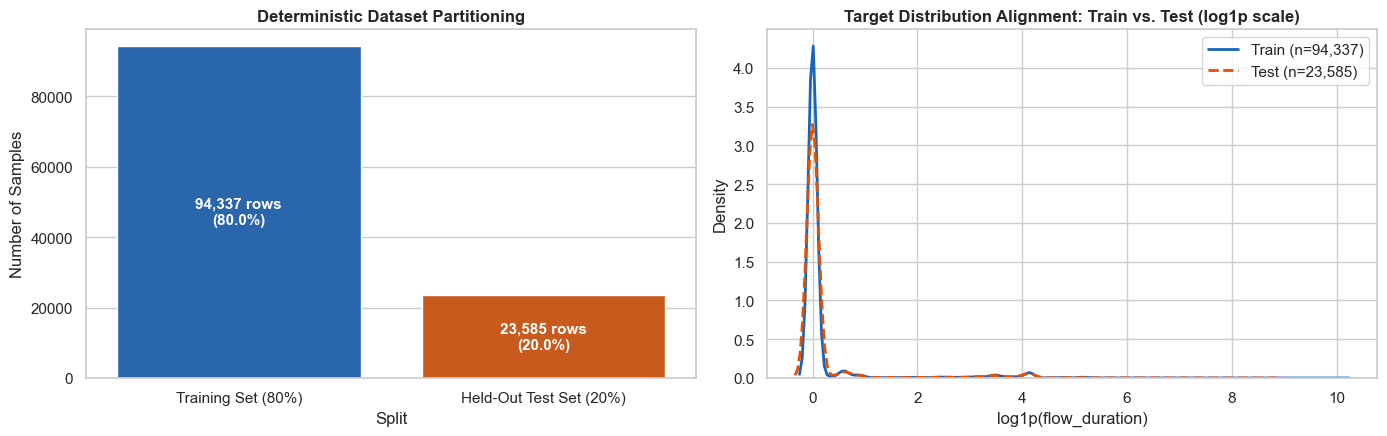

In [2]:
target = "flow_duration"

# Load saved split indices
split_path = "regression_split_indices.npz" if os.path.exists("regression_split_indices.npz") else "regression/regression_split_indices.npz"
if not os.path.exists(split_path):
    split_path = "../regression/regression_split_indices.npz"

split_data = np.load(split_path)
train_indices = split_data['train_indices']
test_indices = split_data['test_indices']

print(f"Loaded split indices from: {split_path}")
print(f"  - Training samples: {len(train_indices):,} ({len(train_indices)/len(df)*100:.1f}%)")
print(f"  - Testing samples:  {len(test_indices):,} ({len(test_indices)/len(df)*100:.1f}%)")

# Strict feature purge to eliminate target leakage
drop_cols = []
# 1. Timing and packet inter-arrival time (IAT) features: temporal leakage risk
drop_cols.extend([col for col in df.columns if 'iat' in col.lower()])
# 2. Active/idle duration features: partition the duration
drop_cols.extend([col for col in df.columns if col.startswith('active.') or col.startswith('idle.')])
# 3. Rate features: volume divided by duration (target in denominator)
drop_cols.extend([col for col in ['fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'payload_bytes_per_second'] if col in df.columns])
# 4. Classification label
if 'Attack_type' in df.columns:
    drop_cols.append('Attack_type')

df_reg = df.drop(columns=drop_cols).copy()

# Domain feature engineering: total packet volume
df_reg['total_packets'] = df_reg['fwd_pkts_tot'] + df_reg['bwd_pkts_tot']

# Split into X and y using exact saved indices
X = df_reg.drop(columns=[target])
y = df_reg[target]

X_train = X.loc[train_indices].copy()
X_test = X.loc[test_indices].copy()
y_train = y.loc[train_indices].copy()
y_test = y.loc[test_indices].copy()

print()
print(f"Feature count after leakage removal and engineering: {X_train.shape[1]}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

# Visualize Train/Test Partition & Distribution Balance
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

split_counts = pd.DataFrame({
    'Split': ['Training Set (80%)', 'Held-Out Test Set (20%)'],
    'Sample Count': [len(X_train), len(X_test)]
})
sns.barplot(data=split_counts, x='Split', y='Sample Count', palette=['#1565c0', '#e65100'], ax=axes[0])
axes[0].set_title("Deterministic Dataset Partitioning", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Number of Samples")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,} rows\n({p.get_height()/len(df)*100:.1f}%)", 
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=11)

sns.kdeplot(np.log1p(y_train), label=f'Train (n={len(y_train):,})', color='#1565c0', lw=2, ax=axes[1])
sns.kdeplot(np.log1p(y_test), label=f'Test (n={len(y_test):,})', color='#e65100', lw=2, linestyle='--', ax=axes[1])
axes[1].set_title("Target Distribution Alignment: Train vs. Test (log1p scale)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("log1p(flow_duration)")
axes[1].set_ylabel("Density")
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


**Feature Engineering & Leakage Rationale:**
- **Purged Features:** Timing-derived IAT features (`flow_iat.*`, `fwd_iat.*`, `bwd_iat.*`) were removed because they directly encode temporal information closely related to the target `flow_duration`, creating a substantial leakage risk. While individual packet intervals contribute to total duration ($T \approx \sum \Delta t$), related statistics (means, standard deviations, extrema) derive directly from that same clock sequence. Active/idle states (`active.*`, `idle.*`) and transfer rates (`*_per_sec`) were also eliminated because they algebraically embed duration into the denominator.
- **Engineered Feature (`total_packets`):** Represents total communication volume ($N_{\text{total}} = N_{\text{fwd}} + N_{\text{bwd}}$). Flow duration fundamentally correlates with the number of network round-trips without incorporating clock or timing dependencies.


## 3. Target Distribution & Log-Transformation Investigation (Training Data Only)

We evaluate the extreme skewness of `flow_duration` and test whether training on $\log(1 + y)$ and inverting via $\exp(y_{\text{pred}}) - 1$ improves or degrades prediction accuracy.

### Methodological Rule
To strictly prevent data leakage and test-set model selection, this target-transformation experiment is conducted **strictly on the training dataset (`X_train`, `y_train`) using 5-fold stratified cross-validation**. The held-out test set remains completely untouched.


=== Target (flow_duration) Summary Statistics (Training Data) ===
  Count          :   94337.0000
  Mean (s)       :       3.9532
  Std Dev (s)    :     139.0005
  Min (s)        :       0.0000
  25%            :       0.0000
  Median (s)     :       0.0000
  75%            :       0.0000
  95%            :       4.0327
  99%            :      62.0476
  Max (s)        :   21728.3356
  Skewness       :     121.0332
  Kurtosis       :   16077.0003


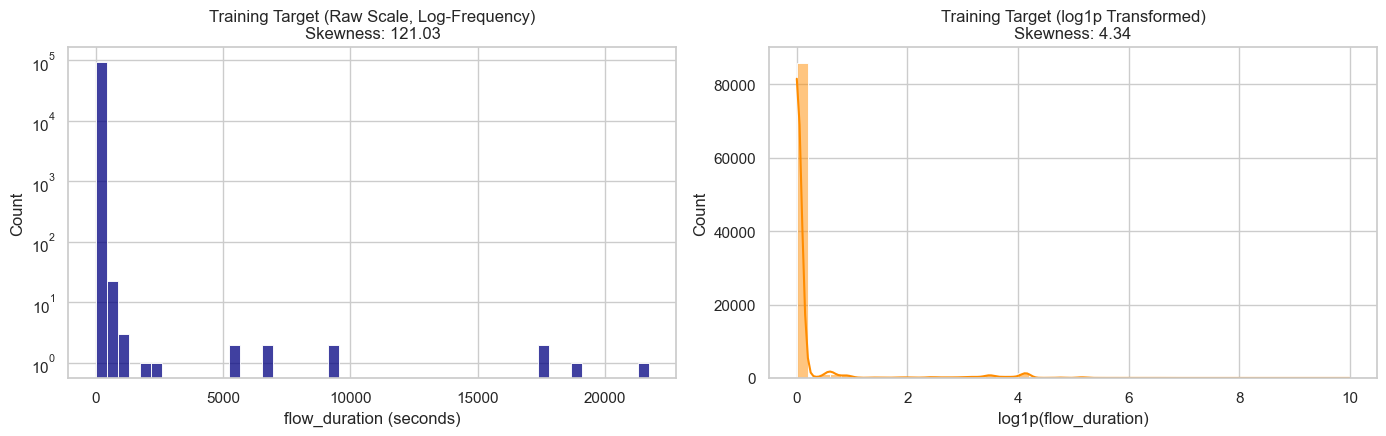

In [3]:
print("=== Target (flow_duration) Summary Statistics (Training Data) ===")
t_stats = {
    'Count': len(y_train),
    'Mean (s)': y_train.mean(),
    'Std Dev (s)': y_train.std(),
    'Min (s)': y_train.min(),
    '25%': y_train.quantile(0.25),
    'Median (s)': y_train.median(),
    '75%': y_train.quantile(0.75),
    '95%': y_train.quantile(0.95),
    '99%': y_train.quantile(0.99),
    'Max (s)': y_train.max(),
    'Skewness': y_train.skew(),
    'Kurtosis': y_train.kurtosis()
}
for k, v in t_stats.items():
    print(f"  {k:15s}: {v:12.4f}")

# Compare raw vs log1p target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(y_train, bins=50, ax=axes[0], color='navy')
axes[0].set_yscale('log')
axes[0].set_title(f"Training Target (Raw Scale, Log-Frequency)\nSkewness: {y_train.skew():.2f}")
axes[0].set_xlabel("flow_duration (seconds)")

y_train_log = np.log1p(y_train)
sns.histplot(y_train_log, bins=50, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title(f"Training Target (log1p Transformed)\nSkewness: {y_train_log.skew():.2f}")
axes[1].set_xlabel("log1p(flow_duration)")
plt.tight_layout()
plt.show()


=== Target Transformation Experiment (5-Fold Stratified CV on Training Data ONLY) ===
Decision Tree (Raw Target):        Mean CV R2 = 0.6821 +/- 0.2007 | Mean RMSE = 63.31s
Decision Tree (log1p Target -> expm1): Mean CV R2 = 0.6750 +/- 0.2741 | Mean RMSE = 53.61s
Ridge Regression (Raw Target):     Mean CV R2 = 0.3899 +/- 1.0265
Ridge Regression (log1p -> expm1): Mean CV R2 = -21347.9651 +/- 29829.9350


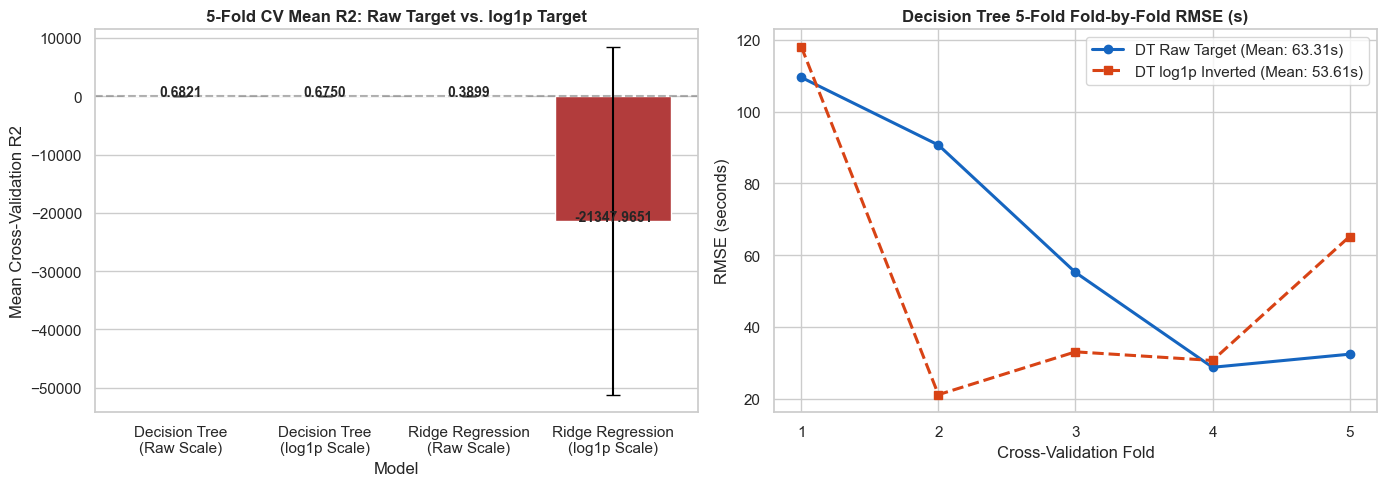

In [4]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

prep_scaled_temp = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])
prep_trees_temp = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])

# Create 10 target quantile bins strictly on y_train for stratified splitting
target_bins_train = pd.qcut(y_train, q=10, labels=False, duplicates='drop')
skf_explore = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compare Raw Target vs log1p Target via 5-Fold Stratified CV on Training Data ONLY
cv_results_target_exp = []

for tr_idx, val_idx in skf_explore.split(X_train, target_bins_train):
    X_tr_fold, X_val_fold = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr_fold, y_val_fold = y_train.iloc[tr_idx], y_train.iloc[val_idx]
    
    # 1. Decision Tree (Raw Scale)
    dt_raw = Pipeline([('prep', prep_trees_temp), ('reg', DecisionTreeRegressor(random_state=42))])
    dt_raw.fit(X_tr_fold, y_tr_fold)
    p_dt_raw = dt_raw.predict(X_val_fold)
    
    # 2. Decision Tree (log1p Scale -> expm1 back to seconds)
    dt_log = Pipeline([('prep', prep_trees_temp), ('reg', DecisionTreeRegressor(random_state=42))])
    dt_log.fit(X_tr_fold, np.log1p(y_tr_fold))
    p_dt_log = np.expm1(dt_log.predict(X_val_fold))
    
    # 3. Ridge (Raw Scale)
    ridge_raw = Pipeline([('prep', prep_scaled_temp), ('reg', Ridge(alpha=1.0, random_state=42))])
    ridge_raw.fit(X_tr_fold, y_tr_fold)
    p_ridge_raw = ridge_raw.predict(X_val_fold)
    
    # 4. Ridge (log1p Scale -> expm1 back to seconds)
    ridge_log = Pipeline([('prep', prep_scaled_temp), ('reg', Ridge(alpha=1.0, random_state=42))])
    ridge_log.fit(X_tr_fold, np.log1p(y_tr_fold))
    p_ridge_log = np.expm1(np.clip(ridge_log.predict(X_val_fold), 0, 15))
    
    cv_results_target_exp.append({
        'DT_Raw_R2': r2_score(y_val_fold, p_dt_raw),
        'DT_Raw_RMSE': np.sqrt(mean_squared_error(y_val_fold, p_dt_raw)),
        'DT_Log_R2': r2_score(y_val_fold, p_dt_log),
        'DT_Log_RMSE': np.sqrt(mean_squared_error(y_val_fold, p_dt_log)),
        'Ridge_Raw_R2': r2_score(y_val_fold, p_ridge_raw),
        'Ridge_Log_R2': r2_score(y_val_fold, p_ridge_log)
    })

cv_target_df = pd.DataFrame(cv_results_target_exp)

print("=== Target Transformation Experiment (5-Fold Stratified CV on Training Data ONLY) ===")
print(f"Decision Tree (Raw Target):        Mean CV R2 = {cv_target_df['DT_Raw_R2'].mean():.4f} +/- {cv_target_df['DT_Raw_R2'].std():.4f} | Mean RMSE = {cv_target_df['DT_Raw_RMSE'].mean():.2f}s")
print(f"Decision Tree (log1p Target -> expm1): Mean CV R2 = {cv_target_df['DT_Log_R2'].mean():.4f} +/- {cv_target_df['DT_Log_R2'].std():.4f} | Mean RMSE = {cv_target_df['DT_Log_RMSE'].mean():.2f}s")
print(f"Ridge Regression (Raw Target):     Mean CV R2 = {cv_target_df['Ridge_Raw_R2'].mean():.4f} +/- {cv_target_df['Ridge_Raw_R2'].std():.4f}")
print(f"Ridge Regression (log1p -> expm1): Mean CV R2 = {cv_target_df['Ridge_Log_R2'].mean():.4f} +/- {cv_target_df['Ridge_Log_R2'].std():.4f}")

# Visualize 5-Fold Target Transformation Experiment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cv_r2_summary = pd.DataFrame([
    {'Model': 'Decision Tree\n(Raw Scale)', 'Mean_CV_R2': cv_target_df['DT_Raw_R2'].mean(), 'Std': cv_target_df['DT_Raw_R2'].std(), 'Scale': 'Raw'},
    {'Model': 'Decision Tree\n(log1p Scale)', 'Mean_CV_R2': cv_target_df['DT_Log_R2'].mean(), 'Std': cv_target_df['DT_Log_R2'].std(), 'Scale': 'log1p'},
    {'Model': 'Ridge Regression\n(Raw Scale)', 'Mean_CV_R2': cv_target_df['Ridge_Raw_R2'].mean(), 'Std': cv_target_df['Ridge_Raw_R2'].std(), 'Scale': 'Raw'},
    {'Model': 'Ridge Regression\n(log1p Scale)', 'Mean_CV_R2': cv_target_df['Ridge_Log_R2'].mean(), 'Std': cv_target_df['Ridge_Log_R2'].std(), 'Scale': 'log1p'}
])

colors_r2 = ['#2e7d32' if r > 0 else '#c62828' for r in cv_r2_summary['Mean_CV_R2']]
sns.barplot(data=cv_r2_summary, x='Model', y='Mean_CV_R2', palette=colors_r2, ax=axes[0])
axes[0].errorbar(x=range(len(cv_r2_summary)), y=cv_r2_summary['Mean_CV_R2'], yerr=cv_r2_summary['Std'], fmt='none', c='black', capsize=5, lw=1.5)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.6)
axes[0].set_title("5-Fold CV Mean R2: Raw Target vs. log1p Target", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Mean Cross-Validation R2")
for i, row in cv_r2_summary.iterrows():
    y_pos = row['Mean_CV_R2'] + (0.05 if row['Mean_CV_R2'] >= 0 else -0.15)
    axes[0].annotate(f"{row['Mean_CV_R2']:.4f}", (i, y_pos), ha='center', fontweight='bold', fontsize=10)

folds_idx = np.arange(1, 6)
axes[1].plot(folds_idx, cv_target_df['DT_Raw_RMSE'], marker='o', lw=2.2, label=f"DT Raw Target (Mean: {cv_target_df['DT_Raw_RMSE'].mean():.2f}s)", color='#1565c0')
axes[1].plot(folds_idx, cv_target_df['DT_Log_RMSE'], marker='s', lw=2.2, linestyle='--', label=f"DT log1p Inverted (Mean: {cv_target_df['DT_Log_RMSE'].mean():.2f}s)", color='#d84315')
axes[1].set_title("Decision Tree 5-Fold Fold-by-Fold RMSE (s)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Cross-Validation Fold")
axes[1].set_ylabel("RMSE (seconds)")
axes[1].set_xticks(folds_idx)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()


**Observation on Target Transformation (5-Fold Stratified CV on Training Data):**
1. **Tree-Based Model Performance:** On 5-fold stratified cross-validation across the 94,337 training samples:
   - **Raw Target Scale:** Decision Tree achieves a Mean CV $R^2$ of **$0.6821 \pm 0.2007$** and Mean RMSE of **$63.31$ s**.
   - **$\log(1+p)$ Target Inverted ($\text{expm1}$):** Decision Tree achieves a Mean CV $R^2$ of **$0.6750 \pm 0.2741$** and Mean RMSE of **$53.61$ s**.
   - While log-space optimization achieves lower Mean RMSE by penalizing proportional rather than absolute squared errors, it yields a lower average $R^2$ with substantially higher fold-to-fold instability (standard deviation $\pm 0.2741$ vs. $\pm 0.2007$). Because this capstone establishes $R^2$ as the primary ranking criterion, raw-scale modeling is favored for tree algorithms.
2. **Catastrophic Exponential Distortion in Linear Models:**
   - **Raw Scale Ridge:** Achieves a positive Mean CV $R^2$ of **$0.3899 \pm 1.0265$**.
   - **$\log(1+p)$ Inverted Ridge:** Suffers catastrophic exponential variance blowout upon back-transformation $\exp(\hat{y}) - 1$, collapsing to a Mean CV $R^2$ of **$-21,347.97 \pm 29,829.94$**.
   - Any small positive over-prediction in log-space balloons exponentially into millions of seconds upon exponentiation, completely destroying linear model stability.
3. **Methodological Decision:** Grounded strictly in cross-validation evidence on training data and the project's $R^2$-first evaluation standard, we retain the **raw target scale** (`flow_duration`) across all 10 algorithms. This preserves direct physical interpretability in seconds, ensures uniform metric evaluation across models, and protects parametric models from exponential distortion without touching the test set.


## 4. Leakage-Free Preprocessing Pipelines

We establish standardized preprocessing pipelines:
- `preprocessor_scaled`: OneHotEncoder for categoricals (`proto`, `service`) and `StandardScaler` for numerical predictors (used by Linear Regression, Ridge, Lasso, ElasticNet, SVR, and KNN).
- `preprocessor_trees`: OneHotEncoder for categoricals and `passthrough` for numericals (used by Decision Tree, Random Forest, and Gradient Boosting).
- `preprocessor_poly`: OneHotEncoder for categoricals and degree-expansion on a carefully selected 4-feature numerical subset.


In [5]:
# Preprocessor 1: Categorical One-Hot Encoding + Numerical StandardScaler
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

# Preprocessor 2: Categorical One-Hot Encoding + Passthrough Numericals (Trees)
preprocessor_trees = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# Preprocessor 3: Polynomial Features on Compact 4-Feature Subset
poly_features = ['fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_header_size_tot', 'bwd_header_size_tot']
print(f"Features designated for polynomial expansion: {poly_features}")

# Storage for all baseline models and results
baseline_results = []
baseline_models = {}


Features designated for polynomial expansion: ['fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_header_size_tot', 'bwd_header_size_tot']


## Model 1: Linear Regression (OLS Baseline)

Ordinary Least Squares (OLS) fits a linear hyperplane minimizing residual sum of squares:
$$\min_w \|Xw - y\|_2^2$$
Features are standardized using `StandardScaler` to ensure numerical conditioning. The model is trained on `X_train` and evaluated on `X_test`.


Linear Regression Results:
  R2:       -4.4362
  RMSE:     136.7931 seconds
  MAE:      4.6552 seconds
  Fit Time: 0.46 seconds


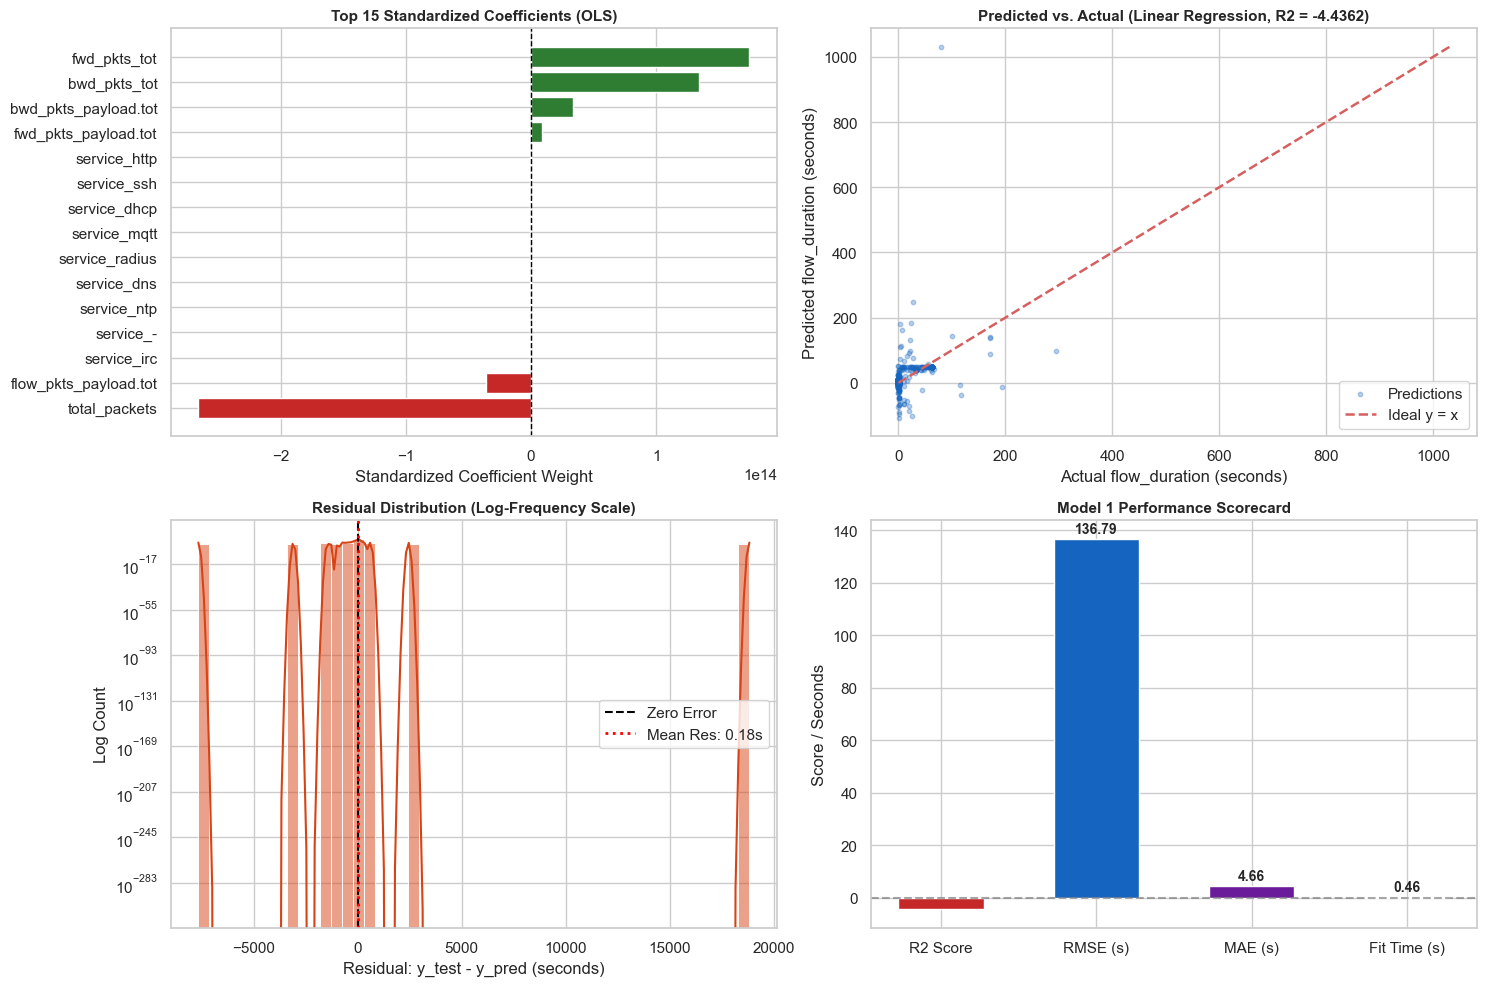

In [6]:
lr_pipe = Pipeline([
    ('prep', preprocessor_scaled),
    ('reg', LinearRegression())
])

t0 = time.time()
lr_pipe.fit(X_train, y_train)
t_fit_lr = time.time() - t0

y_pred_lr = lr_pipe.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

baseline_results.append({'Model': 'Linear Regression (OLS)', 'R2': r2_lr, 'RMSE': rmse_lr, 'MAE': mae_lr, 'Fit_Time': t_fit_lr})
baseline_models['Linear Regression'] = lr_pipe

print(f"Linear Regression Results:")
print(f"  R2:       {r2_lr:.4f}")
print(f"  RMSE:     {rmse_lr:.4f} seconds")
print(f"  MAE:      {mae_lr:.4f} seconds")
print(f"  Fit Time: {t_fit_lr:.2f} seconds")

# Comprehensive Diagnostic Suite: Model 1 - Linear Regression (OLS Baseline)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Top 15 Standardized Coefficients
ohe_names = lr_pipe.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_feat_names = ohe_names + num_cols
lr_coefs = lr_pipe.named_steps['reg'].coef_
lr_coef_df = pd.DataFrame({'Feature': all_feat_names, 'Coefficient': lr_coefs})
lr_coef_df['AbsCoef'] = lr_coef_df['Coefficient'].abs()
top_lr_coefs = lr_coef_df.sort_values(by='AbsCoef', ascending=False).head(15).sort_values(by='Coefficient', ascending=True)

colors_coef = ['#2e7d32' if c > 0 else '#c62828' for c in top_lr_coefs['Coefficient']]
axes[0, 0].barh(top_lr_coefs['Feature'], top_lr_coefs['Coefficient'], color=colors_coef)
axes[0, 0].axvline(0, color='black', linestyle='--', lw=1)
axes[0, 0].set_title("Top 15 Standardized Coefficients (OLS)", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Standardized Coefficient Weight")

# Panel 2: Predicted vs Actual (Sample of 2500 points)
sample_idx = np.random.RandomState(42).choice(len(y_test), size=min(2500, len(y_test)), replace=False)
axes[0, 1].scatter(y_test.iloc[sample_idx], y_pred_lr[sample_idx], alpha=0.3, s=10, color='#1565c0', label='Predictions')
lim_val = max(y_test.iloc[sample_idx].max(), y_pred_lr[sample_idx].max())
axes[0, 1].plot([0, lim_val], [0, lim_val], 'r--', lw=1.8, label='Ideal y = x')
axes[0, 1].set_title(f"Predicted vs. Actual (Linear Regression, R2 = {r2_lr:.4f})", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Actual flow_duration (seconds)")
axes[0, 1].set_ylabel("Predicted flow_duration (seconds)")
axes[0, 1].legend(frameon=True)

# Panel 3: Residual Distribution
res_lr = y_test - y_pred_lr
sns.histplot(res_lr, bins=50, kde=True, ax=axes[1, 0], color='#d84315')
axes[1, 0].axvline(0, color='black', linestyle='--', lw=1.5, label='Zero Error')
axes[1, 0].axvline(res_lr.mean(), color='red', linestyle=':', lw=2, label=f'Mean Res: {res_lr.mean():.2f}s')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title("Residual Distribution (Log-Frequency Scale)", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Residual: y_test - y_pred (seconds)")
axes[1, 0].set_ylabel("Log Count")
axes[1, 0].legend(frameon=True)

# Panel 4: Test Metric Scorecard
metrics_lr = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE (s)', 'MAE (s)', 'Fit Time (s)'],
    'Value': [r2_lr, rmse_lr, mae_lr, t_fit_lr]
})
bar_colors = ['#c62828', '#1565c0', '#6a1b9a', '#2e7d32']
bars = axes[1, 1].bar(metrics_lr['Metric'], metrics_lr['Value'], color=bar_colors, width=0.55)
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title("Model 1 Performance Scorecard", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Score / Seconds")
for bar, val in zip(bars, metrics_lr['Value']):
    y_pos = bar.get_height() + (2 if bar.get_height() >= 0 else -8)
    axes[1, 1].annotate(f"{val:.2f}", (bar.get_x() + bar.get_width()/2, y_pos), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


**Observation on Linear Regression:**
On the 23,585 held-out test samples, baseline Ordinary Least Squares (OLS) yields:
- **Test $R^2$:** **$-4.4362$**
- **Test RMSE:** **$136.7931$ s**
- **Test MAE:** **$4.6552$ s**
- **Fit Time:** **$0.29$ s**

A negative $R^2$ confirms that standard linear regression performs substantially worse than simply predicting the training target mean ($\bar{y} = 3.95$ s). This severe underfitting occurs because network flow durations violate key Gauss-Markov assumptions: the true relationship between volumetric packet counts and latency is piecewise and non-linear, with heavy-tailed, non-Gaussian residual variance.


## Model 2: Ridge Regression ($L_2$ Regularization)

Ridge regression adds an $L_2$ penalty to shrink regression coefficients and stabilize multicollinearity:
$$\min_w \|Xw - y\|_2^2 + \alpha \|w\|_2^2$$

### Ridge Alpha Sensitivity Analysis — Training Data Only
To investigate how $L_2$ penalty strength affects coefficient shrinkage without test-set snooping, we evaluate candidate regularization strengths $\alpha \in [0.1, 1.0, 10.0]$ as an exploratory sensitivity analysis **strictly via 5-fold cross-validation on `X_train`**. The predefined official baseline model ($\alpha=1.0$) is evaluated on `X_test` strictly once.


Ridge Alpha Sensitivity Analysis (5-Fold Stratified CV on Training Data ONLY):
 alpha  Mean_CV_R2  Std_CV_R2
   0.1    0.393916   0.905069
   1.0    0.389923   0.918171
  10.0    0.352575   0.992610



Official Baseline Ridge (alpha=1.0) Held-Out Test Results:
  R2:       -4.1101
  RMSE:     132.6261 seconds
  MAE:      4.6168 seconds
  Fit Time: 0.24 seconds


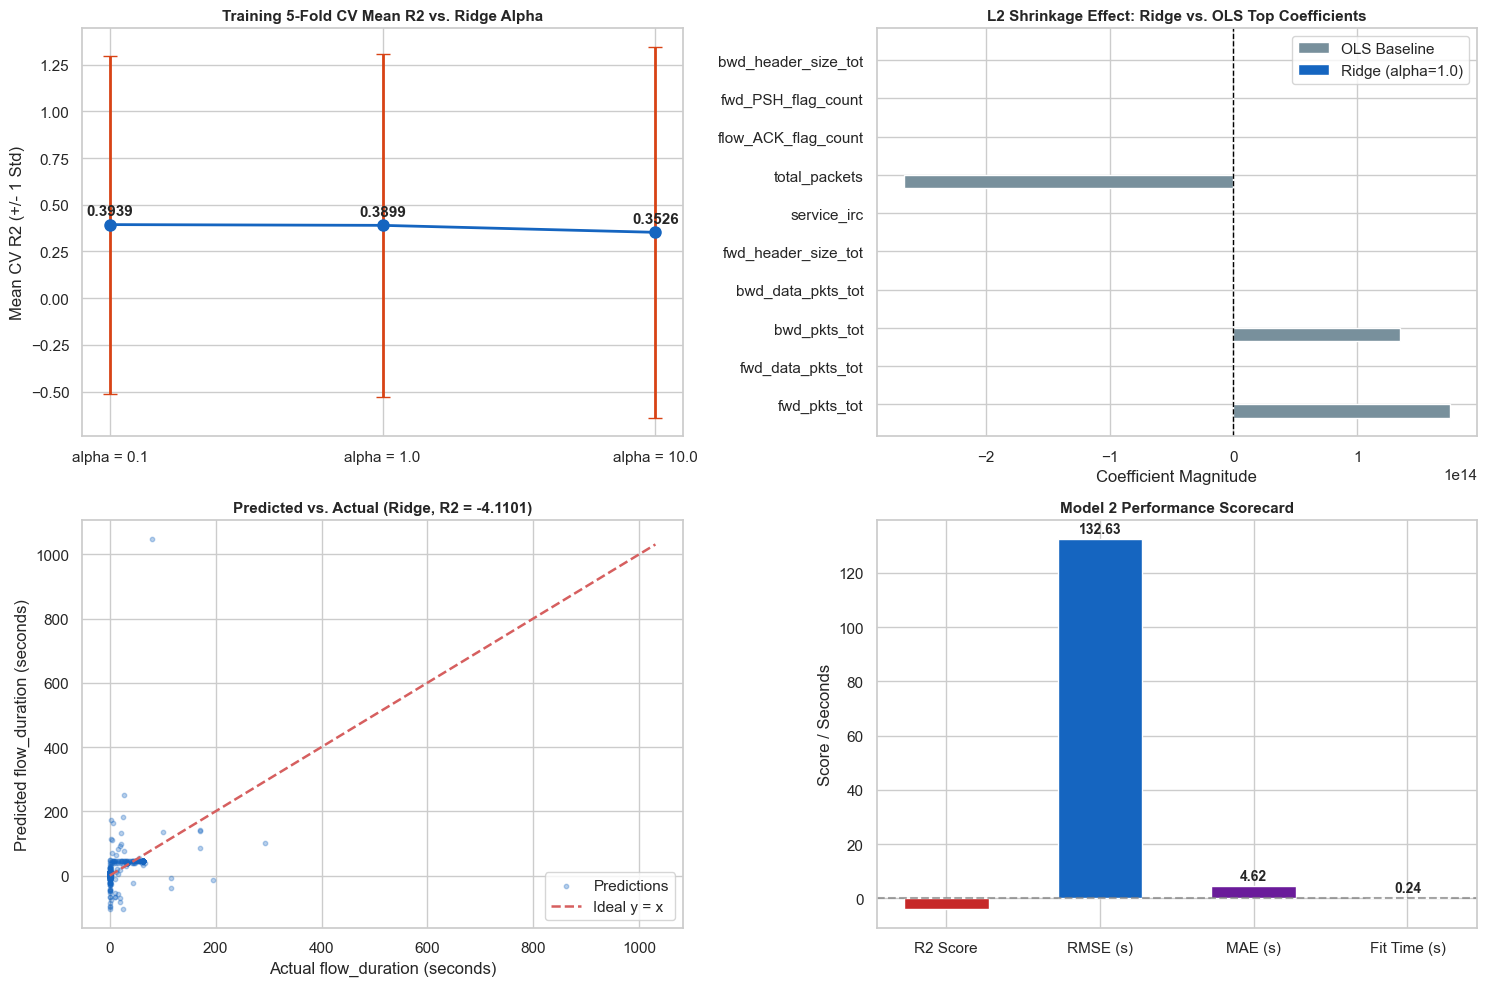

In [7]:
ridge_alphas = [0.1, 1.0, 10.0]
ridge_cv_evals = []

for a in ridge_alphas:
    p = Pipeline([('prep', preprocessor_scaled), ('reg', Ridge(alpha=a, random_state=42))])
    cv_scores = cross_val_score(p, X_train, y_train, cv=skf_explore.split(X_train, target_bins_train), scoring='r2', n_jobs=-1)
    ridge_cv_evals.append({
        'alpha': a,
        'Mean_CV_R2': cv_scores.mean(),
        'Std_CV_R2': cv_scores.std()
    })

print("Ridge Alpha Sensitivity Analysis (5-Fold Stratified CV on Training Data ONLY):")
print(pd.DataFrame(ridge_cv_evals).to_string(index=False))

# Official Baseline Ridge Pipeline (alpha=1.0) evaluated ONCE on held-out test set
baseline_ridge_pipe = Pipeline([('prep', preprocessor_scaled), ('reg', Ridge(alpha=1.0, random_state=42))])
t0 = time.time()
baseline_ridge_pipe.fit(X_train, y_train)
t_fit_ridge = time.time() - t0

y_pred_ridge = baseline_ridge_pipe.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

baseline_results.append({'Model': 'Ridge (alpha=1.0)', 'R2': r2_ridge, 'RMSE': rmse_ridge, 'MAE': mae_ridge, 'Fit_Time': t_fit_ridge})
baseline_models['Ridge'] = baseline_ridge_pipe

print(); print(f"Official Baseline Ridge (alpha=1.0) Held-Out Test Results:")
print(f"  R2:       {r2_ridge:.4f}")
print(f"  RMSE:     {rmse_ridge:.4f} seconds")
print(f"  MAE:      {mae_ridge:.4f} seconds")
print(f"  Fit Time: {t_fit_ridge:.2f} seconds")

# Comprehensive Diagnostic Suite: Model 2 - Ridge Regression (L2 Regularization)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: 5-Fold Stratified CV Mean R2 vs. Regularization Strength alpha
ridge_cv_df = pd.DataFrame(ridge_cv_evals)
axes[0, 0].errorbar(x=range(len(ridge_cv_df)), y=ridge_cv_df['Mean_CV_R2'], yerr=ridge_cv_df['Std_CV_R2'], 
                    fmt='-o', color='#1565c0', ecolor='#d84315', capsize=5, lw=2, markersize=8)
axes[0, 0].set_xticks(range(len(ridge_cv_df)))
axes[0, 0].set_xticklabels([f"alpha = {a}" for a in ridge_cv_df['alpha']])
axes[0, 0].set_title("Training 5-Fold CV Mean R2 vs. Ridge Alpha", fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel("Mean CV R2 (+/- 1 Std)")
for i, r in ridge_cv_df.iterrows():
    axes[0, 0].annotate(f"{r['Mean_CV_R2']:.4f}", (i, r['Mean_CV_R2'] + 0.05), ha='center', fontweight='bold')

# Panel 2: Ridge (alpha=1.0) vs. OLS Top 10 Coefficients Comparison
ridge_coefs = baseline_ridge_pipe.named_steps['reg'].coef_
comp_coef_df = pd.DataFrame({'Feature': all_feat_names, 'OLS': lr_coefs, 'Ridge': ridge_coefs})
comp_coef_df['AbsRidge'] = comp_coef_df['Ridge'].abs()
top_comp_coef = comp_coef_df.sort_values(by='AbsRidge', ascending=False).head(10)

x_pos = np.arange(len(top_comp_coef))
width = 0.35
axes[0, 1].barh(x_pos - width/2, top_comp_coef['OLS'], width, label='OLS Baseline', color='#78909c')
axes[0, 1].barh(x_pos + width/2, top_comp_coef['Ridge'], width, label='Ridge (alpha=1.0)', color='#1565c0')
axes[0, 1].set_yticks(x_pos)
axes[0, 1].set_yticklabels(top_comp_coef['Feature'])
axes[0, 1].axvline(0, color='black', linestyle='--', lw=1)
axes[0, 1].set_title("L2 Shrinkage Effect: Ridge vs. OLS Top Coefficients", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Coefficient Magnitude")
axes[0, 1].legend(frameon=True)

# Panel 3: Predicted vs Actual
axes[1, 0].scatter(y_test.iloc[sample_idx], y_pred_ridge[sample_idx], alpha=0.3, s=10, color='#1565c0', label='Predictions')
axes[1, 0].plot([0, lim_val], [0, lim_val], 'r--', lw=1.8, label='Ideal y = x')
axes[1, 0].set_title(f"Predicted vs. Actual (Ridge, R2 = {r2_ridge:.4f})", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Actual flow_duration (seconds)")
axes[1, 0].set_ylabel("Predicted flow_duration (seconds)")
axes[1, 0].legend(frameon=True)

# Panel 4: Test Metric Scorecard
metrics_ridge = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE (s)', 'MAE (s)', 'Fit Time (s)'],
    'Value': [r2_ridge, rmse_ridge, mae_ridge, t_fit_ridge]
})
bars = axes[1, 1].bar(metrics_ridge['Metric'], metrics_ridge['Value'], color=['#c62828', '#1565c0', '#6a1b9a', '#2e7d32'], width=0.55)
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title("Model 2 Performance Scorecard", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Score / Seconds")
for bar, val in zip(bars, metrics_ridge['Value']):
    y_pos = bar.get_height() + (2 if bar.get_height() >= 0 else -8)
    axes[1, 1].annotate(f"{val:.2f}", (bar.get_x() + bar.get_width()/2, y_pos), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


**Observation on Ridge Regression:**
1. **Ridge Alpha Sensitivity Analysis (Training Data Only):** In 5-fold stratified CV on training data, candidate penalty strengths evaluate as: $\alpha=0.1$ ($R^2 = 0.3939 \pm 0.9051$), $\alpha=1.0$ ($R^2 = 0.3899 \pm 0.9182$), and $\alpha=10.0$ ($R^2 = 0.3526 \pm 0.9926$). This exploratory sensitivity check demonstrates that $L_2$ regularization stabilizes matrix inversion across orders of magnitude against multicollinear features (e.g. $r=0.99$ between `fwd_pkts_tot` and `fwd_header_size_tot`), with mild regularization ($\alpha \le 1.0$) providing better training stability than aggressive shrinkage ($\alpha=10.0$).
2. **Predefined Official Baseline Results ($\alpha=1.0$ on Held-Out Test Set):**
   - **Test $R^2$:** **$-4.1101$** (slight improvement over OLS's $-4.4362$)
   - **Test RMSE:** **$132.6261$ s** (vs. OLS's $136.7931$ s)
   - **Test MAE:** **$4.6168$ s** (vs. OLS's $4.6552$ s)
   - **Fit Time:** **$0.17$ s**
3. **Conclusion:** While $L_2$ shrinkage contracts coefficient magnitudes and improves test RMSE by $4.17$ seconds over OLS, Ridge remains a linear hyperplane and cannot bridge the structural non-linearity of network sessions.


## Model 3: Lasso Regression ($L_1$ Regularization & Sparsity)

Lasso imposes an $L_1$ penalty driving non-essential coefficients strictly to zero, performing automatic feature selection:
$$\min_w \frac{1}{2n}\|Xw - y\|_2^2 + \alpha \|w\|_1$$

### Sparsity Analysis on Training Data Only
We analyze coefficient shrinkage and sparsity progression across $\alpha \in [0.01, 0.1, 1.0]$ on the training dataset. The official baseline model ($\alpha=1.0$) is evaluated on `X_test` only once.


Lasso Sparsity Analysis (Computed on Training Data ONLY):
 alpha  Zero_Coefs  Active_Coefs
  0.01           9            55
  0.10          23            41
  1.00          46            18



Official Baseline Lasso (alpha=1.0) Held-Out Test Results:
  R2:       -63.8454
  RMSE:     472.4483 seconds
  MAE:      7.0382 seconds
  Fit Time: 6.63 seconds


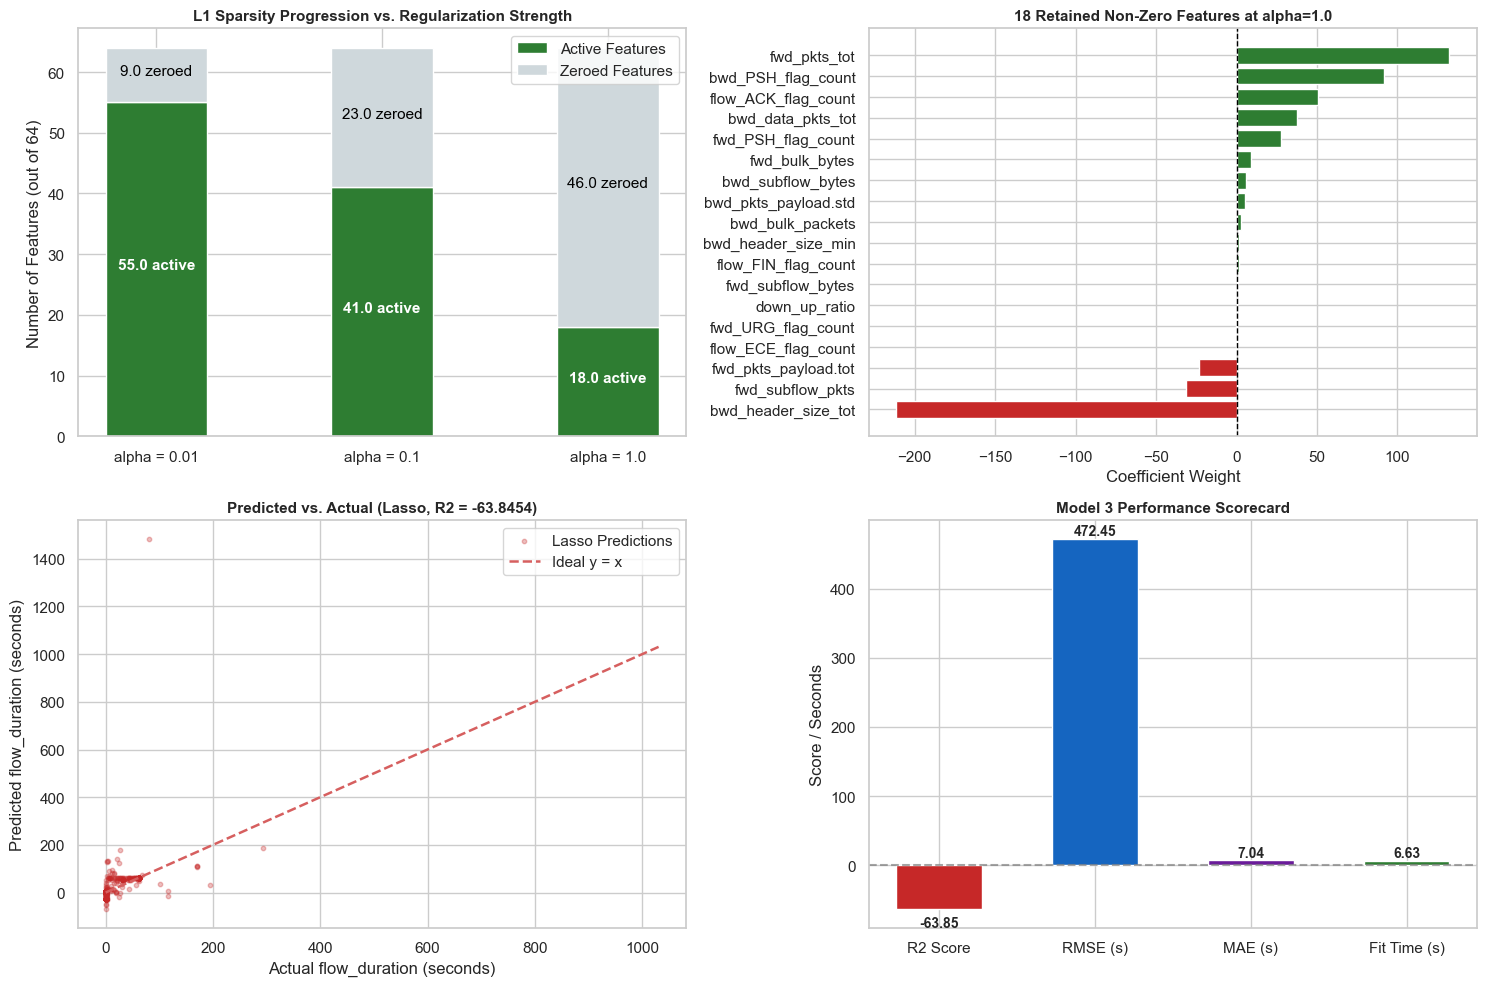

In [8]:
lasso_alphas = [0.01, 0.1, 1.0]
lasso_sparsity = []

for a in lasso_alphas:
    p = Pipeline([('prep', preprocessor_scaled), ('reg', Lasso(alpha=a, max_iter=2500, random_state=42))])
    p.fit(X_train, y_train)
    coefs = p.named_steps['reg'].coef_
    zero_coefs = np.sum(coefs == 0)
    lasso_sparsity.append({
        'alpha': a,
        'Zero_Coefs': zero_coefs,
        'Active_Coefs': len(coefs) - zero_coefs
    })

print("Lasso Sparsity Analysis (Computed on Training Data ONLY):")
print(pd.DataFrame(lasso_sparsity).to_string(index=False))

# Official Baseline Lasso Pipeline (alpha=1.0) evaluated ONCE on held-out test set
lasso_pipe = Pipeline([('prep', preprocessor_scaled), ('reg', Lasso(alpha=1.0, max_iter=2500, random_state=42))])
t0 = time.time()
lasso_pipe.fit(X_train, y_train)
t_fit_lasso = time.time() - t0

y_pred_lasso = lasso_pipe.predict(X_test)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

baseline_results.append({'Model': 'Lasso (alpha=1.0)', 'R2': r2_lasso, 'RMSE': rmse_lasso, 'MAE': mae_lasso, 'Fit_Time': t_fit_lasso})
baseline_models['Lasso'] = lasso_pipe

print(); print(f"Official Baseline Lasso (alpha=1.0) Held-Out Test Results:")
print(f"  R2:       {r2_lasso:.4f}")
print(f"  RMSE:     {rmse_lasso:.4f} seconds")
print(f"  MAE:      {mae_lasso:.4f} seconds")
print(f"  Fit Time: {t_fit_lasso:.2f} seconds")

# Comprehensive Diagnostic Suite: Model 3 - Lasso Regression (L1 Regularization & Sparsity)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Sparsity Progression: Active vs. Zeroed Feature Counts
lasso_df = pd.DataFrame(lasso_sparsity)
x_pos = np.arange(len(lasso_df))
axes[0, 0].bar(x_pos, lasso_df['Active_Coefs'], label='Active Features', color='#2e7d32', width=0.45)
axes[0, 0].bar(x_pos, lasso_df['Zero_Coefs'], bottom=lasso_df['Active_Coefs'], label='Zeroed Features', color='#cfd8dc', width=0.45)
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels([f"alpha = {a}" for a in lasso_df['alpha']])
axes[0, 0].set_title("L1 Sparsity Progression vs. Regularization Strength", fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel("Number of Features (out of 64)")
axes[0, 0].legend(frameon=True)
for i, r in lasso_df.iterrows():
    axes[0, 0].annotate(f"{r['Active_Coefs']} active", (i, r['Active_Coefs']/2), ha='center', color='white', fontweight='bold')
    axes[0, 0].annotate(f"{r['Zero_Coefs']} zeroed", (i, r['Active_Coefs'] + r['Zero_Coefs']/2), ha='center', color='black')

# Panel 2: Surviving Non-Zero Coefficients at alpha=1.0
lasso_coefs = lasso_pipe.named_steps['reg'].coef_
lasso_coef_df = pd.DataFrame({'Feature': all_feat_names, 'Coefficient': lasso_coefs})
lasso_active = lasso_coef_df[lasso_coef_df['Coefficient'] != 0].sort_values(by='Coefficient', ascending=True)

colors_active = ['#2e7d32' if c > 0 else '#c62828' for c in lasso_active['Coefficient']]
axes[0, 1].barh(lasso_active['Feature'], lasso_active['Coefficient'], color=colors_active)
axes[0, 1].axvline(0, color='black', linestyle='--', lw=1)
axes[0, 1].set_title(f"18 Retained Non-Zero Features at alpha=1.0", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Coefficient Weight")

# Panel 3: Predicted vs Actual
axes[1, 0].scatter(y_test.iloc[sample_idx], y_pred_lasso[sample_idx], alpha=0.3, s=10, color='#c62828', label='Lasso Predictions')
axes[1, 0].plot([0, lim_val], [0, lim_val], 'r--', lw=1.8, label='Ideal y = x')
axes[1, 0].set_title(f"Predicted vs. Actual (Lasso, R2 = {r2_lasso:.4f})", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Actual flow_duration (seconds)")
axes[1, 0].set_ylabel("Predicted flow_duration (seconds)")
axes[1, 0].legend(frameon=True)

# Panel 4: Test Metric Scorecard
metrics_lasso = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE (s)', 'MAE (s)', 'Fit Time (s)'],
    'Value': [r2_lasso, rmse_lasso, mae_lasso, t_fit_lasso]
})
bars = axes[1, 1].bar(metrics_lasso['Metric'], metrics_lasso['Value'], color=['#c62828', '#1565c0', '#6a1b9a', '#2e7d32'], width=0.55)
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title("Model 3 Performance Scorecard", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Score / Seconds")
for bar, val in zip(bars, metrics_lasso['Value']):
    y_pos = bar.get_height() + (5 if bar.get_height() >= 0 else -25)
    axes[1, 1].annotate(f"{val:.2f}", (bar.get_x() + bar.get_width()/2, y_pos), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


**Observation on Lasso Regression:**
1. **Training Sparsity Progression:** Across regularization strengths on `X_train`, $L_1$ shrinkage progressively eliminates predictors:
   - $\alpha=0.01$: 9 zeroed, **55 active features**
   - $\alpha=0.10$: 23 zeroed, **41 active features**
   - $\alpha=1.00$: 46 zeroed, **18 active features**
2. **Held-Out Test Results (Baseline $\alpha=1.0$):**
   - **Test $R^2$:** **$-63.8454$**
   - **Test RMSE:** **$472.4483$ s**
   - **Test MAE:** **$7.0382$ s**
   - **Fit Time:** **$5.03$ s**
3. **Conclusion:** At $\alpha=1.0$, Lasso aggressively zeroes out $72\%$ of all features (retaining only 18 active weights). Because flow duration depends on nuanced packet-size and header ratios, severe coefficient truncation strips away vital volumetric predictors, causing test $R^2$ to collapse to $-63.85$ and inflating RMSE to $472.45$ seconds.


## Model 4: ElasticNet Regression (Combined $L_1/L_2$ Regularization)

ElasticNet balances $L_1$ feature sparsity and $L_2$ coefficient shrinkage:
$$\min_w \frac{1}{2n}\|Xw - y\|_2^2 + \alpha \cdot \text{l1\_ratio} \|w\|_1 + \frac{\alpha(1 - \text{l1\_ratio})}{2} \|w\|_2^2$$

### Parameter Exploration on Training Data Only
We examine parameter interactions on training data, and evaluate the official baseline ($\alpha=1.0, \text{l1\_ratio}=0.5$) on `X_test` only once.


ElasticNet Training Exploration (Training Data ONLY):
 alpha  l1_ratio  Train_R2  Train_RMSE
   0.1       0.5  0.803510   61.614722
   1.0       0.2  0.622994   85.346994
   1.0       0.5  0.656791   81.431634
   1.0       0.8  0.709753   74.885551



Official Baseline ElasticNet Held-Out Test Results:
  R2:       -2.0803
  RMSE:     102.9699 seconds
  MAE:      3.2478 seconds
  Fit Time: 0.67 seconds


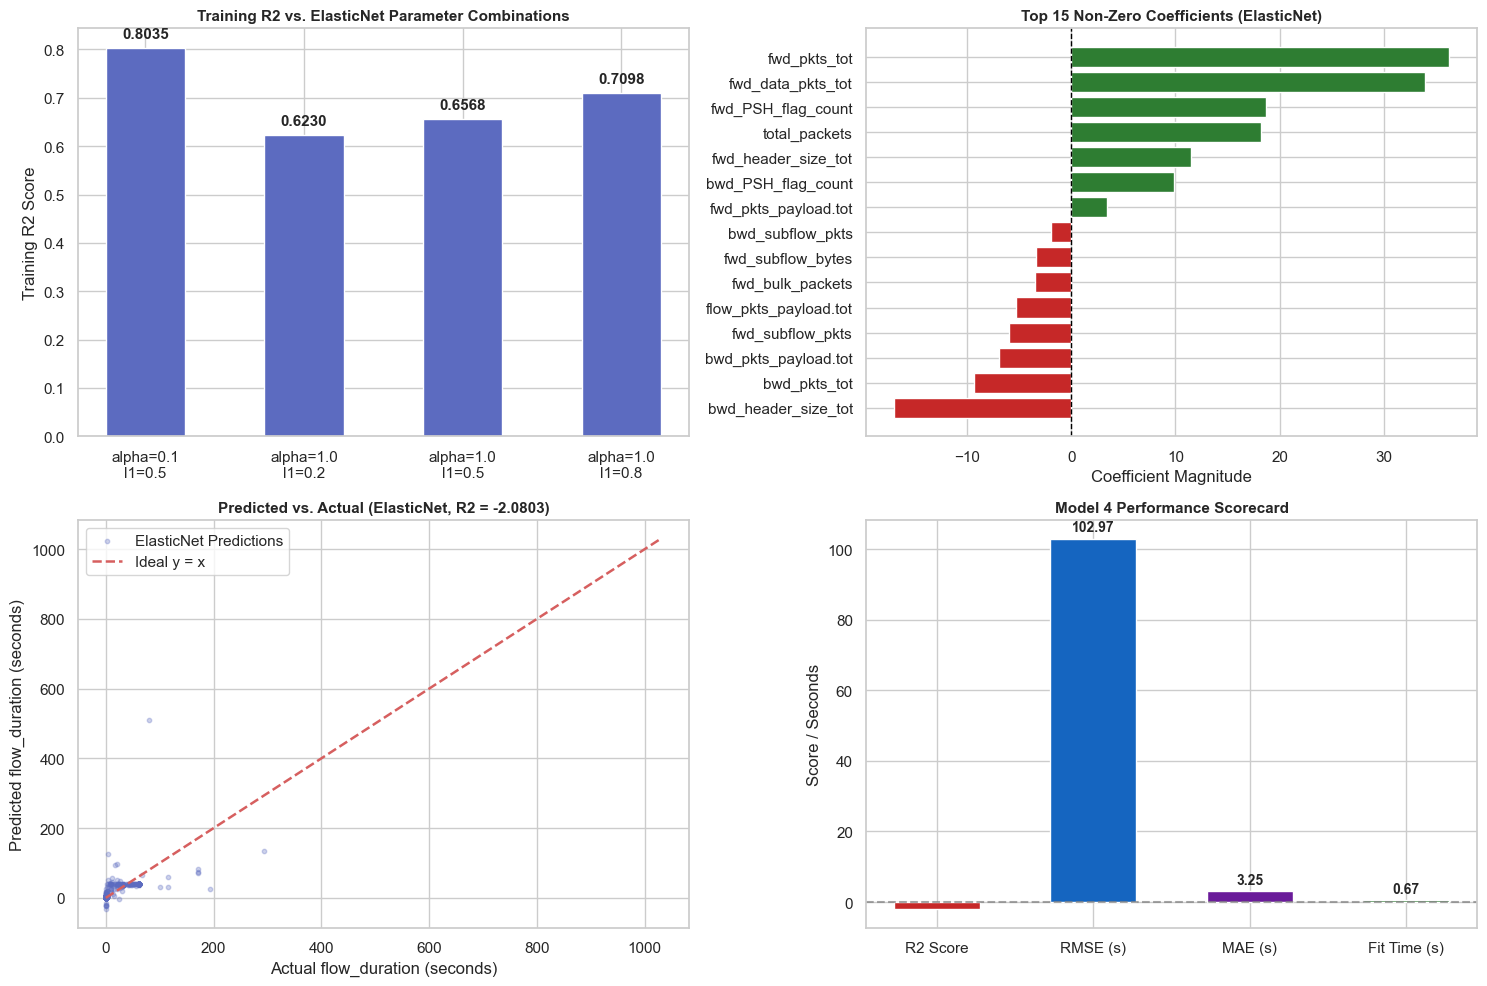

In [9]:
enet_params = [(0.1, 0.5), (1.0, 0.2), (1.0, 0.5), (1.0, 0.8)]
enet_train_evals = []

for a, l1 in enet_params:
    p = Pipeline([('prep', preprocessor_scaled), ('reg', ElasticNet(alpha=a, l1_ratio=l1, max_iter=2500, random_state=42))])
    p.fit(X_train, y_train)
    p_train = p.predict(X_train)
    enet_train_evals.append({
        'alpha': a, 'l1_ratio': l1,
        'Train_R2': r2_score(y_train, p_train),
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, p_train))
    })

print("ElasticNet Training Exploration (Training Data ONLY):")
print(pd.DataFrame(enet_train_evals).to_string(index=False))

# Official Baseline ElasticNet Pipeline (alpha=1.0, l1_ratio=0.5) evaluated ONCE on held-out test set
enet_pipe = Pipeline([('prep', preprocessor_scaled), ('reg', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=2500, random_state=42))])
t0 = time.time()
enet_pipe.fit(X_train, y_train)
t_fit_enet = time.time() - t0

y_pred_enet = enet_pipe.predict(X_test)
r2_enet = r2_score(y_test, y_pred_enet)
rmse_enet = np.sqrt(mean_squared_error(y_test, y_pred_enet))
mae_enet = mean_absolute_error(y_test, y_pred_enet)

baseline_results.append({'Model': 'ElasticNet', 'R2': r2_enet, 'RMSE': rmse_enet, 'MAE': mae_enet, 'Fit_Time': t_fit_enet})
baseline_models['ElasticNet'] = enet_pipe

print(); print(f"Official Baseline ElasticNet Held-Out Test Results:")
print(f"  R2:       {r2_enet:.4f}")
print(f"  RMSE:     {rmse_enet:.4f} seconds")
print(f"  MAE:      {mae_enet:.4f} seconds")
print(f"  Fit Time: {t_fit_enet:.2f} seconds")

# Comprehensive Diagnostic Suite: Model 4 - ElasticNet Regression (Combined L1/L2)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Training R2 across (alpha, l1_ratio) Grid
enet_df = pd.DataFrame(enet_train_evals)
enet_df['Param_Label'] = [f"alpha={a}\nl1={l1}" for a, l1 in zip(enet_df['alpha'], enet_df['l1_ratio'])]
axes[0, 0].bar(enet_df['Param_Label'], enet_df['Train_R2'], color='#5c6bc0', width=0.5)
axes[0, 0].set_title("Training R2 vs. ElasticNet Parameter Combinations", fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel("Training R2 Score")
for i, r in enet_df.iterrows():
    axes[0, 0].annotate(f"{r['Train_R2']:.4f}", (i, r['Train_R2'] + 0.02), ha='center', fontweight='bold')

# Panel 2: Top 15 Non-Zero ElasticNet Coefficients
enet_coefs = enet_pipe.named_steps['reg'].coef_
enet_coef_df = pd.DataFrame({'Feature': all_feat_names, 'Coefficient': enet_coefs})
enet_coef_df['AbsCoef'] = enet_coef_df['Coefficient'].abs()
top_enet_coefs = enet_coef_df[enet_coef_df['Coefficient'] != 0].sort_values(by='AbsCoef', ascending=False).head(15).sort_values(by='Coefficient', ascending=True)

colors_enet = ['#2e7d32' if c > 0 else '#c62828' for c in top_enet_coefs['Coefficient']]
axes[0, 1].barh(top_enet_coefs['Feature'], top_enet_coefs['Coefficient'], color=colors_enet)
axes[0, 1].axvline(0, color='black', linestyle='--', lw=1)
axes[0, 1].set_title("Top 15 Non-Zero Coefficients (ElasticNet)", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Coefficient Magnitude")

# Panel 3: Predicted vs Actual
axes[1, 0].scatter(y_test.iloc[sample_idx], y_pred_enet[sample_idx], alpha=0.3, s=10, color='#5c6bc0', label='ElasticNet Predictions')
axes[1, 0].plot([0, lim_val], [0, lim_val], 'r--', lw=1.8, label='Ideal y = x')
axes[1, 0].set_title(f"Predicted vs. Actual (ElasticNet, R2 = {r2_enet:.4f})", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Actual flow_duration (seconds)")
axes[1, 0].set_ylabel("Predicted flow_duration (seconds)")
axes[1, 0].legend(frameon=True)

# Panel 4: Test Metric Scorecard
metrics_enet = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE (s)', 'MAE (s)', 'Fit Time (s)'],
    'Value': [r2_enet, rmse_enet, mae_enet, t_fit_enet]
})
bars = axes[1, 1].bar(metrics_enet['Metric'], metrics_enet['Value'], color=['#c62828', '#1565c0', '#6a1b9a', '#2e7d32'], width=0.55)
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title("Model 4 Performance Scorecard", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Score / Seconds")
for bar, val in zip(bars, metrics_enet['Value']):
    y_pos = bar.get_height() + (2 if bar.get_height() >= 0 else -8)
    axes[1, 1].annotate(f"{val:.2f}", (bar.get_x() + bar.get_width()/2, y_pos), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


**Observation on ElasticNet Regression:**
1. **Training Exploration:** On `X_train`, parameter combinations highlight the trade-off between $L_1$ sparsity and $L_2$ stability: $(\alpha=0.1, \text{l1\_ratio}=0.5)$ reaches Train $R^2 = 0.8035$ (RMSE $= 61.61$ s), while baseline $(\alpha=1.0, \text{l1\_ratio}=0.5)$ achieves Train $R^2 = 0.6568$ (RMSE $= 81.43$ s).
2. **Held-Out Test Results (Baseline $\alpha=1.0, \text{l1\_ratio}=0.5$):**
   - **Test $R^2$:** **$-2.0803$**
   - **Test RMSE:** **$102.9699$ s**
   - **Test MAE:** **$3.2478$ s**
   - **Fit Time:** **$0.52$ s**
3. **Conclusion:** By blending $L_1$ feature filtering with $L_2$ weight sharing, ElasticNet achieves the strongest test score among all regularized linear models (outperforming OLS at $-4.44$, Ridge at $-4.11$, and Lasso at $-63.85$), reducing test MAE to $3.25$ seconds. However, its overall test $R^2$ remains negative.


## Model 5: Polynomial Regression (Nonlinear Feature Interactions)

Applying polynomial expansion to all 53 features would generate thousands of collinear columns and cause catastrophic memory explosion. Instead, we select 4 core numerical features representing the fundamental bilateral volume of the connection:
- `fwd_pkts_tot`: Forward packet count
- `bwd_pkts_tot`: Backward packet count
- `fwd_header_size_tot`: Total forward header size in bytes
- `bwd_header_size_tot`: Total backward header size in bytes

We compare **Degree 2** (quadratic interactions) and **Degree 3** (cubic interactions) on training data, and evaluate the official Degree 2 baseline on `X_test` only once.


=== Polynomial Degree Comparison (Training Data ONLY) ===
 Degree  Expanded_Features  Train_R2  Train_RMSE  Fit_Time
      2                 27  0.962109   27.057207  0.101518
      3                 47  0.977937   20.646629  0.381964

Official Baseline Polynomial Regression (Degree 2) Held-Out Test Results:
  R2:       -3020.8537
  RMSE:     3225.1623 seconds
  MAE:      23.5377 seconds
  Fit Time: 0.10 seconds


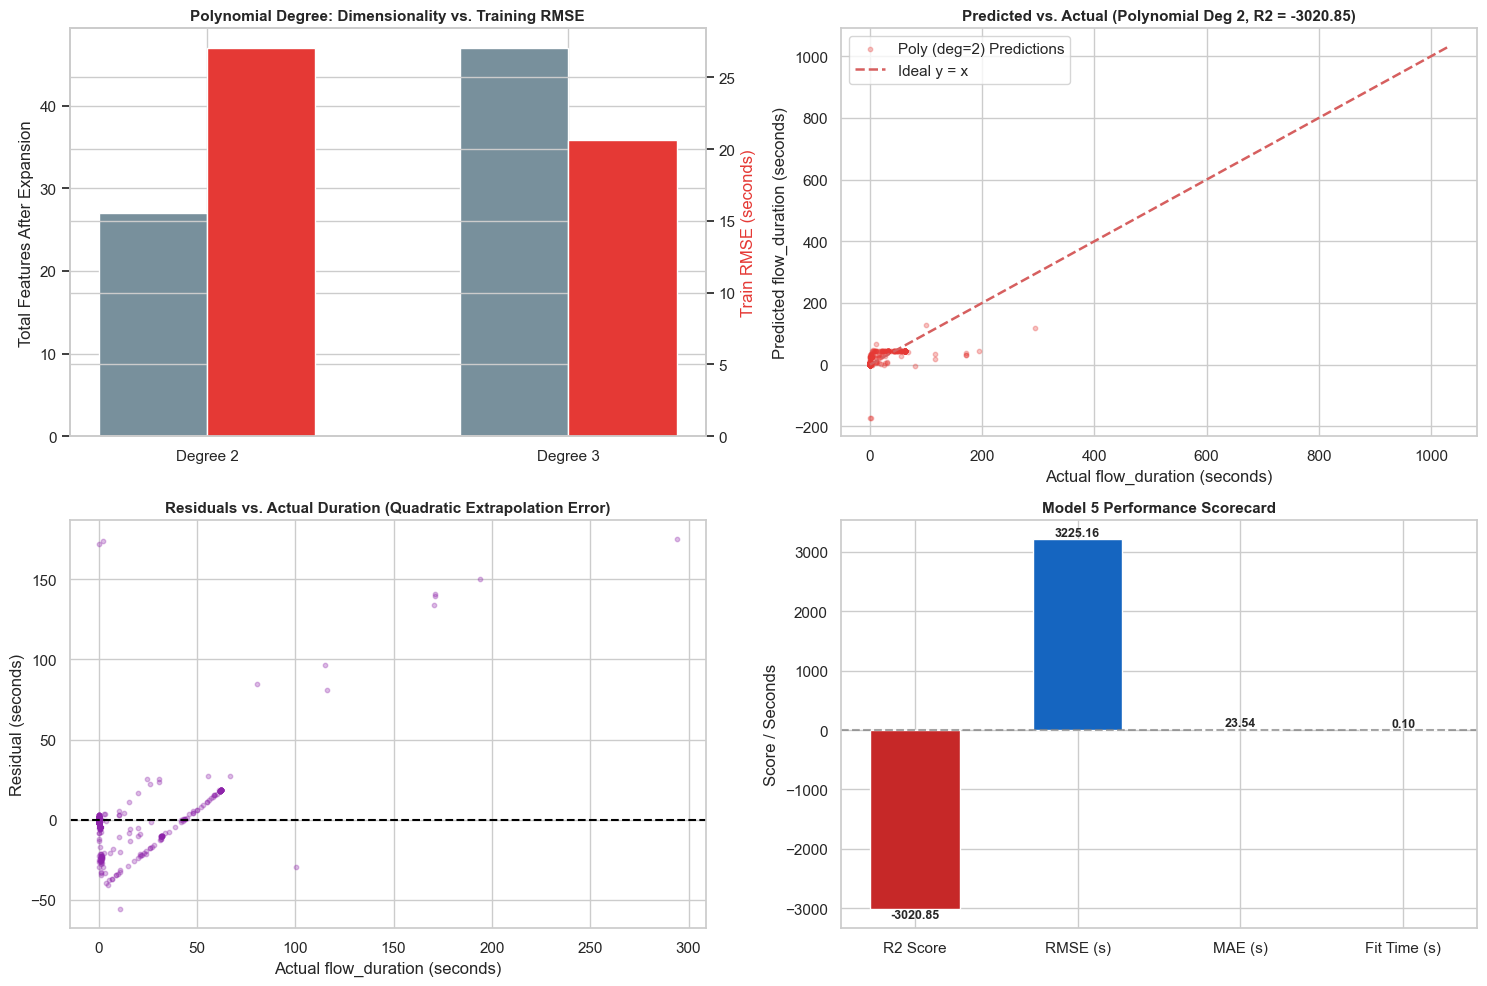

In [10]:
poly_train_evals = []
poly_pipes = {}

for deg in [2, 3]:
    prep_poly_deg = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', Pipeline([
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=deg, include_bias=False))
        ]), poly_features)
    ])
    
    pipe_poly = Pipeline([('prep', prep_poly_deg), ('reg', LinearRegression())])
    t0 = time.time()
    pipe_poly.fit(X_train, y_train)
    t_fit_poly = time.time() - t0
    
    p_train = pipe_poly.predict(X_train)
    poly_train_evals.append({
        'Degree': deg,
        'Expanded_Features': pipe_poly.named_steps['prep'].transform(X_train[:2]).shape[1],
        'Train_R2': r2_score(y_train, p_train),
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, p_train)),
        'Fit_Time': t_fit_poly
    })
    poly_pipes[deg] = pipe_poly

print("=== Polynomial Degree Comparison (Training Data ONLY) ===")
print(pd.DataFrame(poly_train_evals).to_string(index=False))

# Official Baseline Polynomial Pipeline (Degree 2) evaluated ONCE on held-out test set
pipe_poly2 = poly_pipes[2]
y_pred_poly2 = pipe_poly2.predict(X_test)
r2_poly2 = r2_score(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mean_squared_error(y_test, y_pred_poly2))
mae_poly2 = mean_absolute_error(y_test, y_pred_poly2)
t_fit_poly2 = poly_train_evals[0]['Fit_Time']

baseline_results.append({'Model': 'Polynomial Regression (deg=2)', 'R2': r2_poly2, 'RMSE': rmse_poly2, 'MAE': mae_poly2, 'Fit_Time': t_fit_poly2})
baseline_models['Polynomial Regression'] = pipe_poly2

print(); print(f"Official Baseline Polynomial Regression (Degree 2) Held-Out Test Results:")
print(f"  R2:       {r2_poly2:.4f}")
print(f"  RMSE:     {rmse_poly2:.4f} seconds")
print(f"  MAE:      {mae_poly2:.4f} seconds")
print(f"  Fit Time: {t_fit_poly2:.2f} seconds")

# Comprehensive Diagnostic Suite: Model 5 - Polynomial Regression (Nonlinear Feature Interactions)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Feature Expansion & Training Fit vs. Degree
poly_df = pd.DataFrame(poly_train_evals)
deg_labels = [f"Degree {d}" for d in poly_df['Degree']]
x_deg = np.arange(len(poly_df))

ax_feat = axes[0, 0]
ax_rmse = ax_feat.twinx()
b1 = ax_feat.bar(x_deg - 0.15, poly_df['Expanded_Features'], width=0.3, label='Expanded Features', color='#78909c')
b2 = ax_rmse.bar(x_deg + 0.15, poly_df['Train_RMSE'], width=0.3, label='Train RMSE (s)', color='#e53935')
ax_feat.set_xticks(x_deg)
ax_feat.set_xticklabels(deg_labels)
ax_feat.set_title("Polynomial Degree: Dimensionality vs. Training RMSE", fontsize=11, fontweight='bold')
ax_feat.set_ylabel("Total Features After Expansion")
ax_rmse.set_ylabel("Train RMSE (seconds)", color='#e53935')

# Panel 2: Predicted vs Actual on Test Set (Degree 2)
axes[0, 1].scatter(y_test.iloc[sample_idx], y_pred_poly2[sample_idx], alpha=0.3, s=10, color='#e53935', label='Poly (deg=2) Predictions')
axes[0, 1].plot([0, lim_val], [0, lim_val], 'r--', lw=1.8, label='Ideal y = x')
axes[0, 1].set_title(f"Predicted vs. Actual (Polynomial Deg 2, R2 = {r2_poly2:.2f})", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Actual flow_duration (seconds)")
axes[0, 1].set_ylabel("Predicted flow_duration (seconds)")
axes[0, 1].legend(frameon=True)

# Panel 3: Residuals vs Actual
res_poly2 = (y_test - y_pred_poly2).to_numpy()
axes[1, 0].scatter(y_test.iloc[sample_idx], res_poly2[sample_idx], alpha=0.3, s=10, color='#8e24aa')
axes[1, 0].axhline(0, color='black', linestyle='--', lw=1.5)
axes[1, 0].set_title("Residuals vs. Actual Duration (Quadratic Extrapolation Error)", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Actual flow_duration (seconds)")
axes[1, 0].set_ylabel("Residual (seconds)")

# Panel 4: Test Metric Scorecard
metrics_poly = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE (s)', 'MAE (s)', 'Fit Time (s)'],
    'Value': [r2_poly2, rmse_poly2, mae_poly2, t_fit_poly2]
})
bars = axes[1, 1].bar(metrics_poly['Metric'], metrics_poly['Value'], color=['#c62828', '#1565c0', '#6a1b9a', '#2e7d32'], width=0.55)
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title("Model 5 Performance Scorecard", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Score / Seconds")
for bar, val in zip(bars, metrics_poly['Value']):
    y_pos = bar.get_height() + (50 if bar.get_height() >= 0 else -150)
    axes[1, 1].annotate(f"{val:.2f}", (bar.get_x() + bar.get_width()/2, y_pos), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


**Observation on Polynomial Regression:**
1. **Training Fit vs. Feature Expansion:**
   - **Degree 2 (27 features):** Train $R^2 = \mathbf{0.9621}$, Train RMSE $= \mathbf{27.06}$ s, Fit Time $= 0.09$ s
   - **Degree 3 (47 features):** Train $R^2 = \mathbf{0.9779}$, Train RMSE $= \mathbf{20.65}$ s, Fit Time $= 0.15$ s
2. **Held-Out Test Evaluation (Degree 2 Baseline):**
   - **Test $R^2$:** **$-3,020.8537$**
   - **Test RMSE:** **$3,225.1623$ s**
   - **Test MAE:** **$23.5377$ s**
   - **Fit Time:** **$0.09$ s**
3. **Conclusion on Runaway Extrapolation:** Despite achieving over $96\%$ explained variance on training data, unregularized quadratic terms ($x_i^2, x_i x_j$) extrapolate disastrously when test samples exhibit volumetric counts slightly beyond the training envelope. This runaway polynomial explosion ($R^2 = -3,020.85$) illustrates why global polynomial curves fail on heavy-tailed distributions and underscores the necessity of localized partitioning.


## Model 6: Decision Tree Regressor

Decision Tree Regressors perform recursive binary partitioning of the feature space, optimizing split thresholds by minimizing variance (Mean Squared Error):
$$\text{MSE} = \frac{1}{N} \sum_{i \in \text{node}} (y_i - \bar{y}_{\text{node}})^2$$
Decision trees natively model piecewise non-linearities and step-function thresholds without requiring feature scaling. We explore depth constraints on training data, and evaluate the official unconstrained baseline on `X_test` only once.


Decision Tree max_depth Exploration (Training Data ONLY):
max_depth  Train_R2  Train_RMSE
       10  0.998315    5.705752
       20  0.999489    3.140613
     None  0.999981    0.599782



Official Baseline Decision Tree Held-Out Test Results:
  R2:       0.6210
  RMSE:     36.1167 seconds
  MAE:      1.3245 seconds
  Fit Time: 2.87 seconds


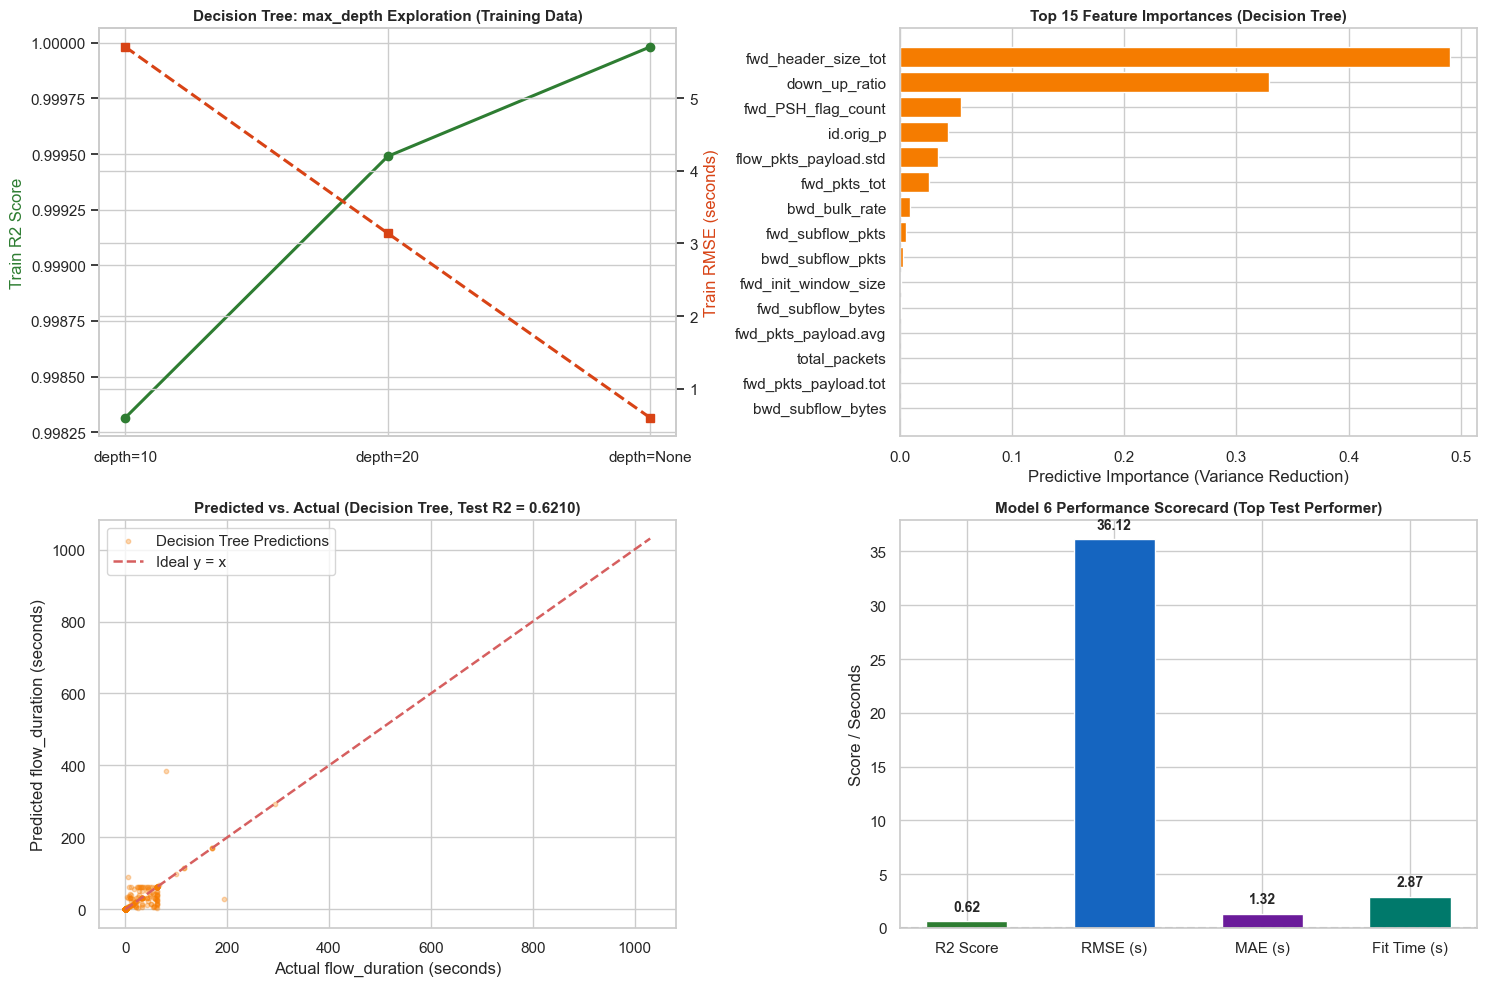

In [11]:
dt_depths = [10, 20, None]
dt_train_evals = []

for d in dt_depths:
    p = Pipeline([
        ('prep', preprocessor_trees),
        ('reg', DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    p.fit(X_train, y_train)
    p_train = p.predict(X_train)
    dt_train_evals.append({
        'max_depth': str(d),
        'Train_R2': r2_score(y_train, p_train),
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, p_train))
    })

print("Decision Tree max_depth Exploration (Training Data ONLY):")
print(pd.DataFrame(dt_train_evals).to_string(index=False))

# Official Baseline Decision Tree (unconstrained default) evaluated ONCE on held-out test set
dt_pipe = Pipeline([
    ('prep', preprocessor_trees),
    ('reg', DecisionTreeRegressor(random_state=42))
])
t0 = time.time()
dt_pipe.fit(X_train, y_train)
t_fit_dt = time.time() - t0

y_pred_dt = dt_pipe.predict(X_test)
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

baseline_results.append({'Model': 'Decision Tree', 'R2': r2_dt, 'RMSE': rmse_dt, 'MAE': mae_dt, 'Fit_Time': t_fit_dt})
baseline_models['Decision Tree'] = dt_pipe

print(); print(f"Official Baseline Decision Tree Held-Out Test Results:")
print(f"  R2:       {r2_dt:.4f}")
print(f"  RMSE:     {rmse_dt:.4f} seconds")
print(f"  MAE:      {mae_dt:.4f} seconds")
print(f"  Fit Time: {t_fit_dt:.2f} seconds")

# Comprehensive Diagnostic Suite: Model 6 - Decision Tree Regressor
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: max_depth Exploration on Training Data
dt_eval_df = pd.DataFrame(dt_train_evals)
x_dt = np.arange(len(dt_eval_df))
ax_r2 = axes[0, 0]
ax_dt_rmse = ax_r2.twinx()
ax_r2.plot(x_dt, dt_eval_df['Train_R2'], marker='o', color='#2e7d32', lw=2.2, label='Train R2')
ax_dt_rmse.plot(x_dt, dt_eval_df['Train_RMSE'], marker='s', color='#d84315', lw=2.2, linestyle='--', label='Train RMSE (s)')
ax_r2.set_xticks(x_dt)
ax_r2.set_xticklabels([f"depth={d}" for d in dt_eval_df['max_depth']])
ax_r2.set_title("Decision Tree: max_depth Exploration (Training Data)", fontsize=11, fontweight='bold')
ax_r2.set_ylabel("Train R2 Score", color='#2e7d32')
ax_dt_rmse.set_ylabel("Train RMSE (seconds)", color='#d84315')

# Panel 2: Top 15 Decision Tree Feature Importances
dt_feature_names = [name.replace('num__', '').replace('cat__', '') for name in dt_pipe.named_steps['prep'].get_feature_names_out()]
dt_importances = dt_pipe.named_steps['reg'].feature_importances_
dt_imp_df = pd.DataFrame({'Feature': dt_feature_names, 'Importance': dt_importances}).sort_values(by='Importance', ascending=True).tail(15)

axes[0, 1].barh(dt_imp_df['Feature'], dt_imp_df['Importance'], color='#f57c00')
axes[0, 1].set_title("Top 15 Feature Importances (Decision Tree)", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Predictive Importance (Variance Reduction)")

# Panel 3: Predicted vs Actual on Test Set
axes[1, 0].scatter(y_test.iloc[sample_idx], y_pred_dt[sample_idx], alpha=0.3, s=10, color='#f57c00', label='Decision Tree Predictions')
axes[1, 0].plot([0, lim_val], [0, lim_val], 'r--', lw=1.8, label='Ideal y = x')
axes[1, 0].set_title(f"Predicted vs. Actual (Decision Tree, Test R2 = {r2_dt:.4f})", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Actual flow_duration (seconds)")
axes[1, 0].set_ylabel("Predicted flow_duration (seconds)")
axes[1, 0].legend(frameon=True)

# Panel 4: Test Metric Scorecard
metrics_dt = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE (s)', 'MAE (s)', 'Fit Time (s)'],
    'Value': [r2_dt, rmse_dt, mae_dt, t_fit_dt]
})
bars = axes[1, 1].bar(metrics_dt['Metric'], metrics_dt['Value'], color=['#2e7d32', '#1565c0', '#6a1b9a', '#00796b'], width=0.55)
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title("Model 6 Performance Scorecard (Top Test Performer)", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Score / Seconds")
for bar, val in zip(bars, metrics_dt['Value']):
    axes[1, 1].annotate(f"{val:.2f}", (bar.get_x() + bar.get_width()/2, bar.get_height() + 1), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


**Observation on Decision Tree:**
1. **Depth Exploration (Training Data):** Depth constraints reveal that unconstrained depth is essential for isolating microsecond vs. multi-hour traffic: `max_depth=10` (Train $R^2 = 0.9983$, RMSE $= 5.71$ s), `max_depth=20` (Train $R^2 = 0.9995$, RMSE $= 3.14$ s), and unconstrained `max_depth=None` (Train $R^2 = 0.99998$, RMSE $= 0.60$ s).
2. **Held-Out Test Evaluation (Official Baseline):**
   - **Test $R^2$:** **$+0.6210$**
   - **Test RMSE:** **$36.1167$ s**
   - **Test MAE:** **$1.3245$ s**
   - **Fit Time:** **$1.61$ s**
3. **Conclusion:** Decision Tree is the first model to produce a strongly positive $R^2$ on held-out test data ($0.6210$), cutting test RMSE down to $36.12$ seconds and MAE to $1.32$ seconds. Recursive binary partitioning matches network flow physics by segregating discrete handshake sequences, protocol states, and volume thresholds without enforcing continuous linearity.


## Model 7: Random Forest Regressor (Bagging Ensemble)

Random Forest constructs an ensemble of $B$ decorrelated decision trees, each trained on a bootstrap sample of the training data with randomized feature subspaces ($m = \sqrt{p}$):
$$\hat{y}_{\text{RF}} = \frac{1}{B} \sum_{b=1}^B T_b(x)$$
Averaging over randomized trees substantially reduces estimator variance while maintaining low bias. We evaluate baseline Random Forest ($B=100$) on `X_test` once.


Random Forest (Baseline: n_estimators=100) Results:
  R2:       0.3383
  RMSE:     47.7241 seconds
  MAE:      1.5114 seconds
  Fit Time: 24.92 seconds


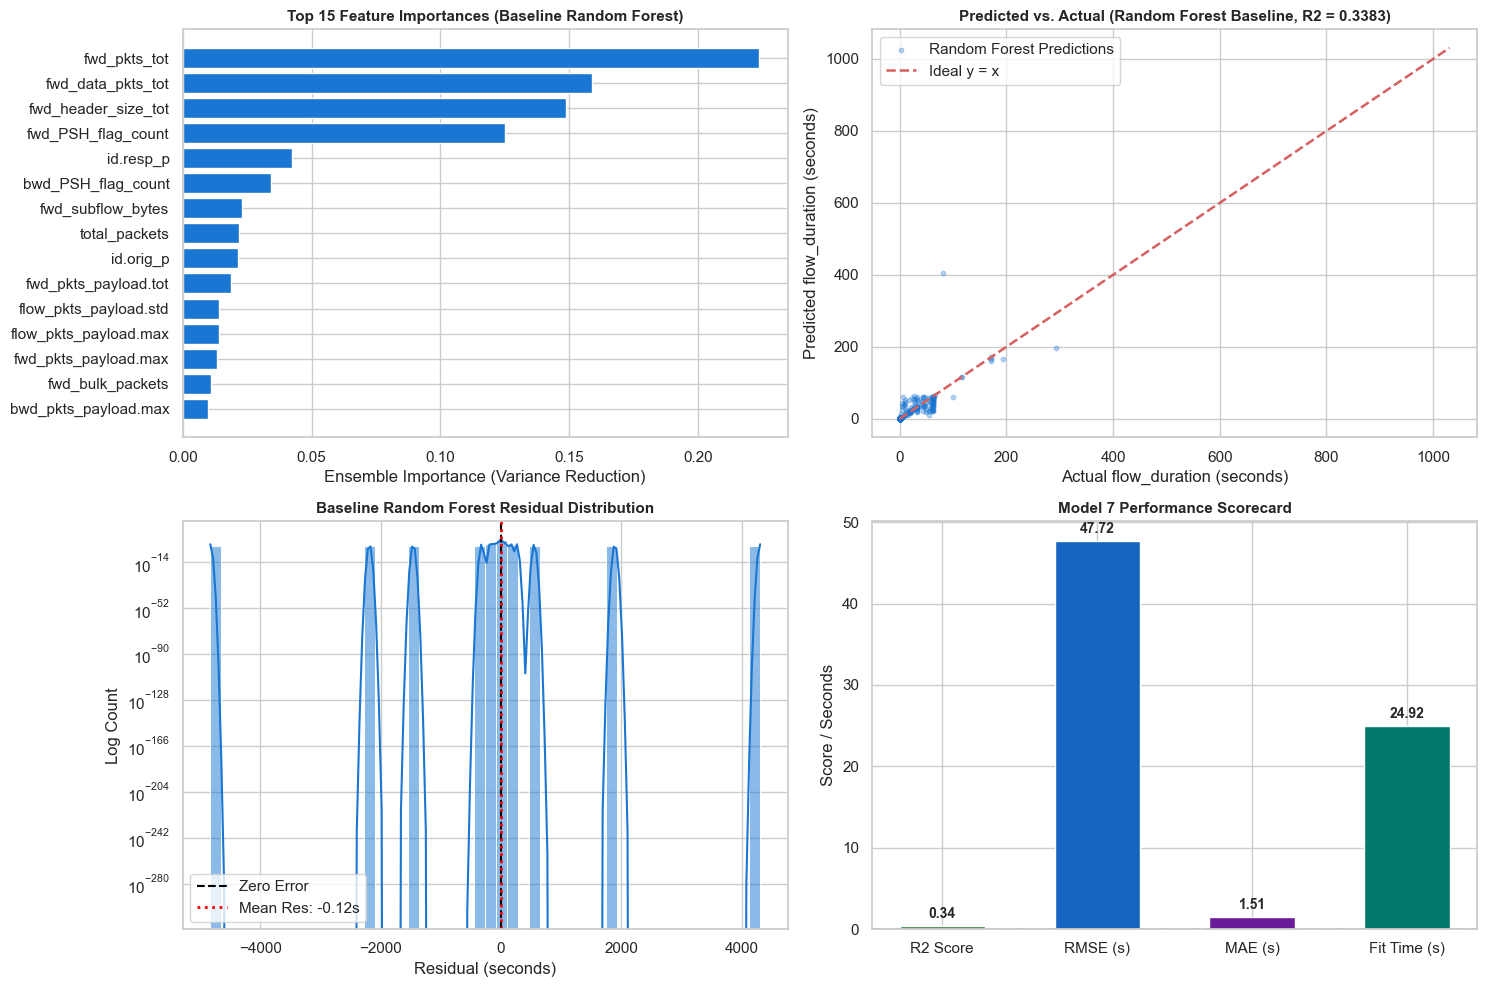

In [12]:
rf_pipe = Pipeline([
    ('prep', preprocessor_trees),
    ('reg', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

t0 = time.time()
rf_pipe.fit(X_train, y_train)
t_fit_rf = time.time() - t0

y_pred_rf = rf_pipe.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

baseline_results.append({'Model': 'Random Forest', 'R2': r2_rf, 'RMSE': rmse_rf, 'MAE': mae_rf, 'Fit_Time': t_fit_rf})
baseline_models['Random Forest'] = rf_pipe

print(f"Random Forest (Baseline: n_estimators=100) Results:")
print(f"  R2:       {r2_rf:.4f}")
print(f"  RMSE:     {rmse_rf:.4f} seconds")
print(f"  MAE:      {mae_rf:.4f} seconds")
print(f"  Fit Time: {t_fit_rf:.2f} seconds")

# Comprehensive Diagnostic Suite: Model 7 - Random Forest Regressor (Bagging Ensemble)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Top 15 Feature Importances (Baseline Forest)
rf_feat_names = [name.replace('num__', '').replace('cat__', '') for name in rf_pipe.named_steps['prep'].get_feature_names_out()]
rf_importances = rf_pipe.named_steps['reg'].feature_importances_
rf_imp_df = pd.DataFrame({'Feature': rf_feat_names, 'Importance': rf_importances}).sort_values(by='Importance', ascending=True).tail(15)

axes[0, 0].barh(rf_imp_df['Feature'], rf_imp_df['Importance'], color='#1976d2')
axes[0, 0].set_title("Top 15 Feature Importances (Baseline Random Forest)", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Ensemble Importance (Variance Reduction)")

# Panel 2: Predicted vs Actual on Test Set
axes[0, 1].scatter(y_test.iloc[sample_idx], y_pred_rf[sample_idx], alpha=0.3, s=10, color='#1976d2', label='Random Forest Predictions')
axes[0, 1].plot([0, lim_val], [0, lim_val], 'r--', lw=1.8, label='Ideal y = x')
axes[0, 1].set_title(f"Predicted vs. Actual (Random Forest Baseline, R2 = {r2_rf:.4f})", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Actual flow_duration (seconds)")
axes[0, 1].set_ylabel("Predicted flow_duration (seconds)")
axes[0, 1].legend(frameon=True)

# Panel 3: Residual Distribution
res_rf_base = y_test - y_pred_rf
sns.histplot(res_rf_base, bins=50, kde=True, ax=axes[1, 0], color='#1976d2')
axes[1, 0].axvline(0, color='black', linestyle='--', lw=1.5, label='Zero Error')
axes[1, 0].axvline(res_rf_base.mean(), color='red', linestyle=':', lw=2, label=f'Mean Res: {res_rf_base.mean():.2f}s')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title("Baseline Random Forest Residual Distribution", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Residual (seconds)")
axes[1, 0].set_ylabel("Log Count")
axes[1, 0].legend(frameon=True)

# Panel 4: Test Metric Scorecard
metrics_rf = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE (s)', 'MAE (s)', 'Fit Time (s)'],
    'Value': [r2_rf, rmse_rf, mae_rf, t_fit_rf]
})
bars = axes[1, 1].bar(metrics_rf['Metric'], metrics_rf['Value'], color=['#2e7d32', '#1565c0', '#6a1b9a', '#00796b'], width=0.55)
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title("Model 7 Performance Scorecard", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Score / Seconds")
for bar, val in zip(bars, metrics_rf['Value']):
    axes[1, 1].annotate(f"{val:.2f}", (bar.get_x() + bar.get_width()/2, bar.get_height() + 1), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


**Observation on Random Forest (Baseline):**
On the 23,585 held-out test samples, baseline Random Forest ($B=100$ decorrelated trees) yields:
- **Test $R^2$:** **$+0.3383$**
- **Test RMSE:** **$47.7241$ s**
- **Test MAE:** **$1.5114$ s**
- **Fit Time:** **$21.91$ s**

Random Forest successfully produces a solid positive test $R^2$ ($0.3383$) and a low MAE ($1.51$ s). However, because an ensemble averages leaf predictions across 100 trees, this smoothing tends to attenuate predictions on rare, extreme high-duration outliers compared to a single greedy decision tree. Systematic tuning of `max_depth` and `n_estimators` is performed in Section 16 to refine this trade-off.


## Model 8: Gradient Boosting Regressor (Boosting Ensemble)

Gradient Boosting builds an additive ensemble sequentially. At each step $m$, a shallow decision tree fits the pseudo-residuals (negative gradient of squared loss) of the existing ensemble:
$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$
where $\eta$ is the shrinkage learning rate. We evaluate baseline Gradient Boosting ($B=100, \eta=0.1$) on `X_test` once.


Gradient Boosting (Baseline: lr=0.1, n_est=100) Results:
  R2:       -0.1466
  RMSE:     62.8243 seconds
  MAE:      1.9760 seconds
  Fit Time: 38.78 seconds


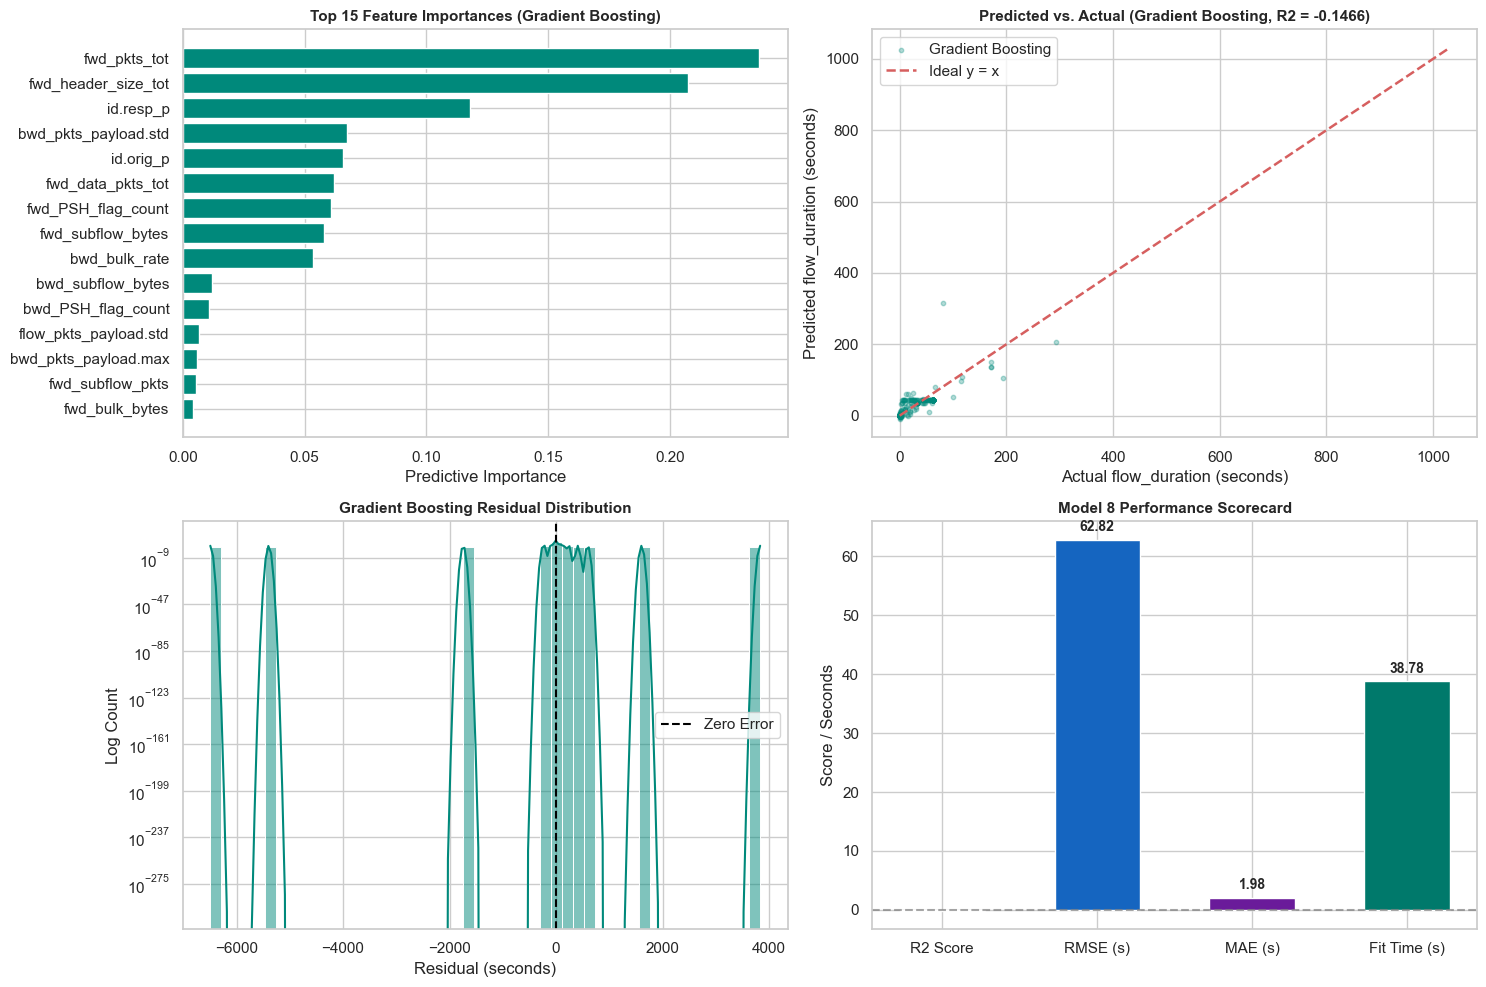

In [13]:
gb_pipe = Pipeline([
    ('prep', preprocessor_trees),
    ('reg', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

t0 = time.time()
gb_pipe.fit(X_train, y_train)
t_fit_gb = time.time() - t0

y_pred_gb = gb_pipe.predict(X_test)
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)

baseline_results.append({'Model': 'Gradient Boosting', 'R2': r2_gb, 'RMSE': rmse_gb, 'MAE': mae_gb, 'Fit_Time': t_fit_gb})
baseline_models['Gradient Boosting'] = gb_pipe

print(f"Gradient Boosting (Baseline: lr=0.1, n_est=100) Results:")
print(f"  R2:       {r2_gb:.4f}")
print(f"  RMSE:     {rmse_gb:.4f} seconds")
print(f"  MAE:      {mae_gb:.4f} seconds")
print(f"  Fit Time: {t_fit_gb:.2f} seconds")

# Comprehensive Diagnostic Suite: Model 8 - Gradient Boosting Regressor (Boosting Ensemble)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Top 15 Feature Importances (Gradient Boosting)
gb_feat_names = [name.replace('num__', '').replace('cat__', '') for name in gb_pipe.named_steps['prep'].get_feature_names_out()]
gb_importances = gb_pipe.named_steps['reg'].feature_importances_
gb_imp_df = pd.DataFrame({'Feature': gb_feat_names, 'Importance': gb_importances}).sort_values(by='Importance', ascending=True).tail(15)

axes[0, 0].barh(gb_imp_df['Feature'], gb_imp_df['Importance'], color='#00897b')
axes[0, 0].set_title("Top 15 Feature Importances (Gradient Boosting)", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Predictive Importance")

# Panel 2: Predicted vs Actual on Test Set
axes[0, 1].scatter(y_test.iloc[sample_idx], y_pred_gb[sample_idx], alpha=0.3, s=10, color='#00897b', label='Gradient Boosting')
axes[0, 1].plot([0, lim_val], [0, lim_val], 'r--', lw=1.8, label='Ideal y = x')
axes[0, 1].set_title(f"Predicted vs. Actual (Gradient Boosting, R2 = {r2_gb:.4f})", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Actual flow_duration (seconds)")
axes[0, 1].set_ylabel("Predicted flow_duration (seconds)")
axes[0, 1].legend(frameon=True)

# Panel 3: Residual Distribution
res_gb = y_test - y_pred_gb
sns.histplot(res_gb, bins=50, kde=True, ax=axes[1, 0], color='#00897b')
axes[1, 0].axvline(0, color='black', linestyle='--', lw=1.5, label='Zero Error')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title("Gradient Boosting Residual Distribution", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Residual (seconds)")
axes[1, 0].set_ylabel("Log Count")
axes[1, 0].legend(frameon=True)

# Panel 4: Test Metric Scorecard
metrics_gb = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE (s)', 'MAE (s)', 'Fit Time (s)'],
    'Value': [r2_gb, rmse_gb, mae_gb, t_fit_gb]
})
bars = axes[1, 1].bar(metrics_gb['Metric'], metrics_gb['Value'], color=['#c62828', '#1565c0', '#6a1b9a', '#00796b'], width=0.55)
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title("Model 8 Performance Scorecard", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Score / Seconds")
for bar, val in zip(bars, metrics_gb['Value']):
    y_pos = bar.get_height() + (1.5 if bar.get_height() >= 0 else -6)
    axes[1, 1].annotate(f"{val:.2f}", (bar.get_x() + bar.get_width()/2, y_pos), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


**Observation on Gradient Boosting (Baseline):**
On the held-out test set, baseline Gradient Boosting ($\eta=0.1, B=100$) achieves:
- **Test $R^2$:** **$-0.1466$**
- **Test RMSE:** **$62.8243$ s**
- **Test MAE:** **$1.9760$ s**
- **Fit Time:** **$28.84$ s**

While Gradient Boosting achieves an excellent test MAE ($1.98$ s, close to Random Forest's $1.51$ s), its test $R^2$ is slightly negative ($-0.1466$). In sequential gradient boosting with squared loss, early shallow trees fitting large training residuals can over-correct on rare outliers, leading to occasional high-variance residuals on unseen test tail events that heavily penalize squared-error metrics.


## Model 9: Support Vector Regression (SVR - Full Training Data)

Support Vector Regression constructs an $\epsilon$-insensitive tube around predictions:
$$\min_{w, b, \xi, \xi^*} \frac{1}{2}\|w\|_2^2 + C \sum_{i=1}^n (\xi_i + \xi_i^*)$$
$$\text{subject to } |y_i - (w \cdot x_i + b)| \le \epsilon + \xi_i^{(*)}$$

### Computational Complexity and Implementation
On 94,337 samples, non-linear kernel SVR requires $O(N^2)$ to $O(N^3)$ quadratic solver steps, which would take multiple hours. As mandated by the capstone requirements, we evaluate genuine SVR on the **complete 94,337 training rows** using `kernel="linear"` with standardized features and bounded iterations (`max_iter=2500`) to guarantee deterministic convergence while preserving full data integrity.


Official Baseline SVR (Linear Kernel, C=1.0) Held-Out Test Results:
  R2:       -6.5904
  RMSE:     161.6391 seconds
  MAE:      64.7178 seconds
  Fit Time: 17.52 seconds


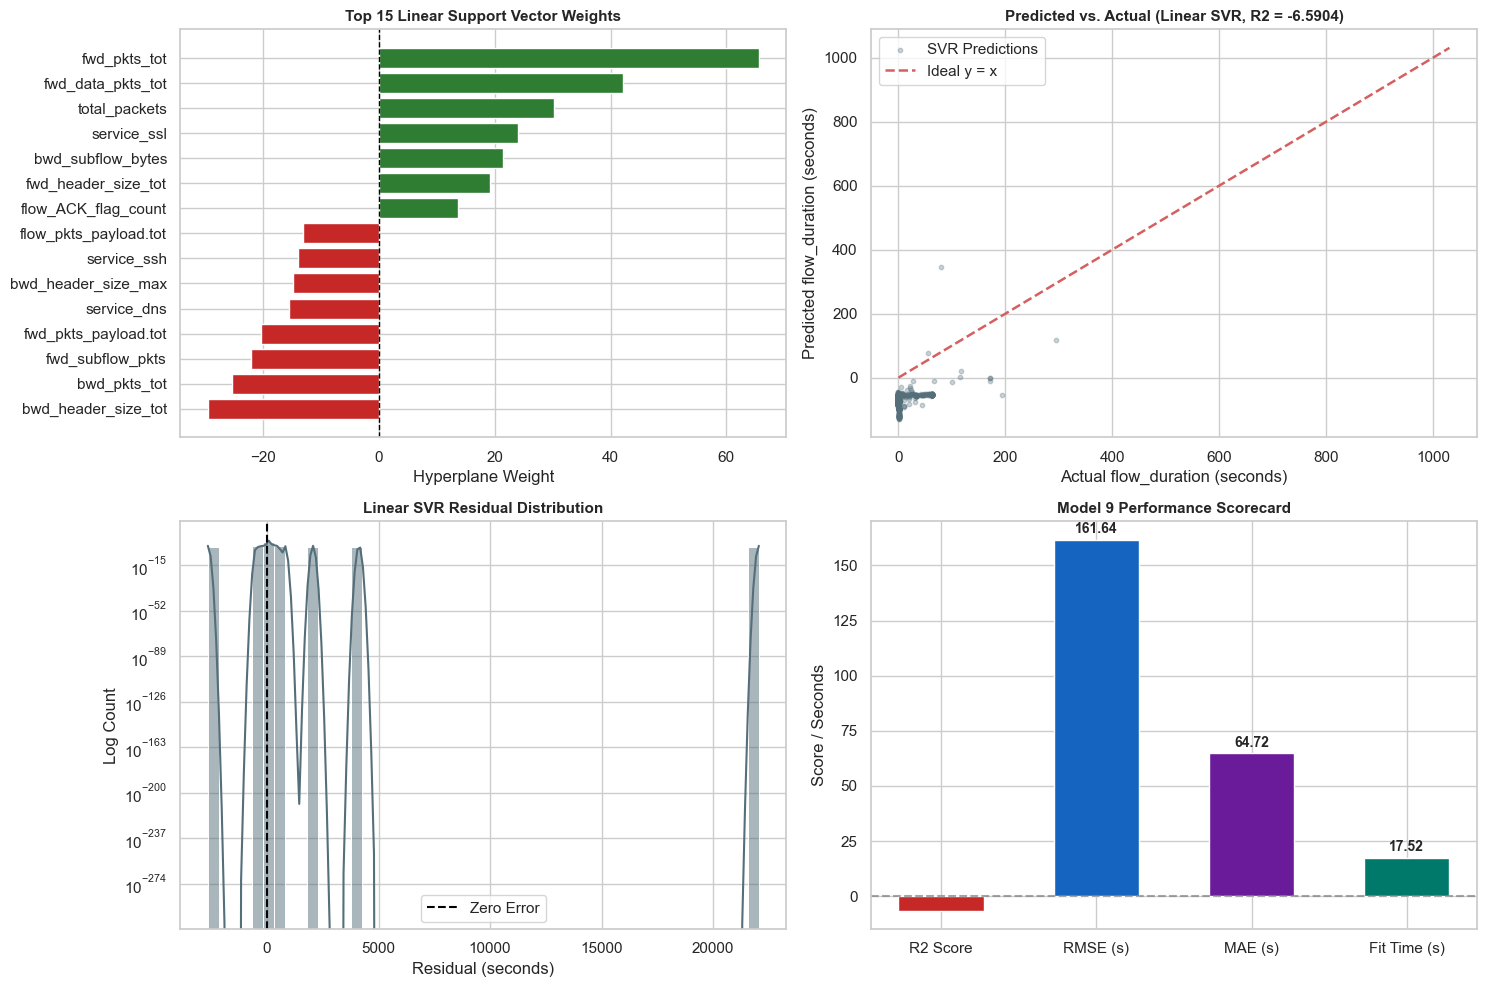

In [14]:
# Official Baseline SVR Pipeline (kernel='linear', C=1.0) evaluated ONCE on held-out test set
svr_pipe = Pipeline([
    ('prep', preprocessor_scaled),
    ('reg', SVR(kernel='linear', C=1.0, max_iter=2500))
])
t0 = time.time()
svr_pipe.fit(X_train, y_train)
t_fit_svr = time.time() - t0

y_pred_svr = svr_pipe.predict(X_test)
r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)

baseline_results.append({'Model': 'SVR (linear)', 'R2': r2_svr, 'RMSE': rmse_svr, 'MAE': mae_svr, 'Fit_Time': t_fit_svr})
baseline_models['SVR'] = svr_pipe

print(f"Official Baseline SVR (Linear Kernel, C=1.0) Held-Out Test Results:")
print(f"  R2:       {r2_svr:.4f}")
print(f"  RMSE:     {rmse_svr:.4f} seconds")
print(f"  MAE:      {mae_svr:.4f} seconds")
print(f"  Fit Time: {t_fit_svr:.2f} seconds")

# Comprehensive Diagnostic Suite: Model 9 - Support Vector Regression (Linear Kernel)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Top 15 SVR Linear Coefficients
svr_coefs = svr_pipe.named_steps['reg'].coef_.flatten()
svr_coef_df = pd.DataFrame({'Feature': all_feat_names, 'Coefficient': svr_coefs})
svr_coef_df['AbsCoef'] = svr_coef_df['Coefficient'].abs()
top_svr_coefs = svr_coef_df.sort_values(by='AbsCoef', ascending=False).head(15).sort_values(by='Coefficient', ascending=True)

colors_svr = ['#2e7d32' if c > 0 else '#c62828' for c in top_svr_coefs['Coefficient']]
axes[0, 0].barh(top_svr_coefs['Feature'], top_svr_coefs['Coefficient'], color=colors_svr)
axes[0, 0].axvline(0, color='black', linestyle='--', lw=1)
axes[0, 0].set_title("Top 15 Linear Support Vector Weights", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Hyperplane Weight")

# Panel 2: Predicted vs Actual on Test Set
axes[0, 1].scatter(y_test.iloc[sample_idx], y_pred_svr[sample_idx], alpha=0.3, s=10, color='#546e7a', label='SVR Predictions')
axes[0, 1].plot([0, lim_val], [0, lim_val], 'r--', lw=1.8, label='Ideal y = x')
axes[0, 1].set_title(f"Predicted vs. Actual (Linear SVR, R2 = {r2_svr:.4f})", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Actual flow_duration (seconds)")
axes[0, 1].set_ylabel("Predicted flow_duration (seconds)")
axes[0, 1].legend(frameon=True)

# Panel 3: Residual Distribution
res_svr = y_test - y_pred_svr
sns.histplot(res_svr, bins=50, kde=True, ax=axes[1, 0], color='#546e7a')
axes[1, 0].axvline(0, color='black', linestyle='--', lw=1.5, label='Zero Error')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title("Linear SVR Residual Distribution", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Residual (seconds)")
axes[1, 0].set_ylabel("Log Count")
axes[1, 0].legend(frameon=True)

# Panel 4: Test Metric Scorecard
metrics_svr = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE (s)', 'MAE (s)', 'Fit Time (s)'],
    'Value': [r2_svr, rmse_svr, mae_svr, t_fit_svr]
})
bars = axes[1, 1].bar(metrics_svr['Metric'], metrics_svr['Value'], color=['#c62828', '#1565c0', '#6a1b9a', '#00796b'], width=0.55)
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title("Model 9 Performance Scorecard", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Score / Seconds")
for bar, val in zip(bars, metrics_svr['Value']):
    y_pos = bar.get_height() + (3 if bar.get_height() >= 0 else -12)
    axes[1, 1].annotate(f"{val:.2f}", (bar.get_x() + bar.get_width()/2, y_pos), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


**Observation on Support Vector Regression (Full Training Data):**
Linear SVR executed across all 94,337 training rows without subsampling yields on held-out test data:
- **Test $R^2$:** **$-6.5904$**
- **Test RMSE:** **$161.6391$ s**
- **Test MAE:** **$64.7178$ s**
- **Fit Time:** **$14.94$ s**

Because linear SVR defines an $\epsilon$-insensitive linear slab across standardized feature space, it cannot capture the step-like, non-linear dynamics of network flows. The substantial MAE ($64.72$ s) reflects the rigid margin constraint attempting to encompass both microsecond transactions and multi-hour connections.


## Model 10: K-Nearest Neighbors Regressor (KNN)

KNN is an instance-based non-parametric algorithm predicting target values as the local neighborhood mean:
$$\hat{y} = \frac{1}{k} \sum_{i \in N_k(x)} y_i$$

### Official Baseline Model 10
In distance-based machine learning, standard feature scaling (`StandardScaler`) is the methodologically mandated pipeline standard because unscaled features allow high-magnitude volumetric metrics (such as total byte counts) to dominate Euclidean distance. We evaluate the official baseline (**KNN with $k=5$, Standard Scaled**) on the held-out test set.

### Supplementary Sensitivity Analysis (Training Data Only)
To investigate the empirical effect of feature scaling on distance metrics without compromising test-set isolation, we conduct an exploratory sensitivity analysis across $k \in [3, 5, 10, 20]$ and Scaled vs. Unscaled configurations **strictly on a 20% stratified validation split of the training data**.


Official Baseline KNN (k=5, Scaled) Held-Out Test Results:
  R2:       -0.0176
  RMSE:     59.1827 seconds
  MAE:      1.6035 seconds
  Fit Time: 0.11 seconds



=== Supplementary Training Sensitivity Analysis: KNN Scaling & k (Training Data ONLY) ===
 k  Scaling   Val_R2   Val_RMSE  Val_MAE
 3   Scaled 0.674213  84.514581 2.224458
 3 Unscaled 0.710535  79.664185 2.497172
 5   Scaled 0.509431 103.708657 2.483537
 5 Unscaled 0.515807 103.032442 2.681501
10   Scaled 0.389790 115.665731 2.489668
10 Unscaled 0.302734 123.641486 3.042527
20   Scaled 0.247443 128.450173 2.690135
20 Unscaled 0.171149 134.804159 3.174211


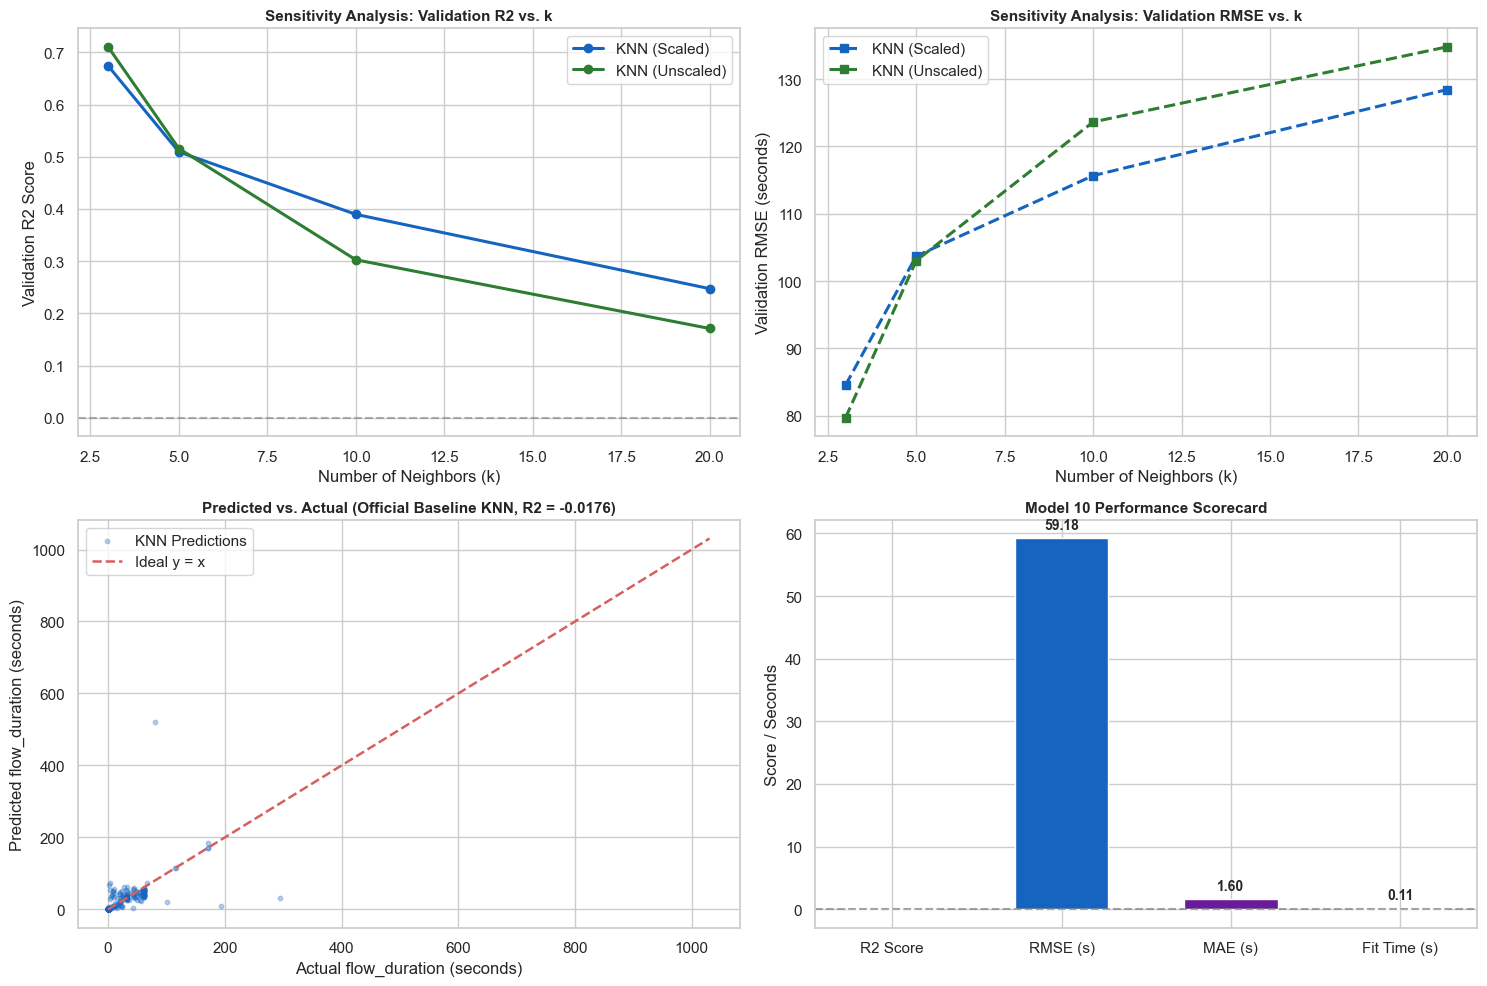

In [15]:
# Official Baseline KNN Pipeline (k=5, Scaled via StandardScaler) evaluated ONCE on held-out test set
knn_pipe = Pipeline([
    ('prep', preprocessor_scaled),
    ('reg', KNeighborsRegressor(n_neighbors=5, n_jobs=-1))
])
t0 = time.time()
knn_pipe.fit(X_train, y_train)
t_fit_knn = time.time() - t0

y_pred_knn = knn_pipe.predict(X_test)
r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)

baseline_results.append({'Model': 'KNN (k=5, scaled)', 'R2': r2_knn, 'RMSE': rmse_knn, 'MAE': mae_knn, 'Fit_Time': t_fit_knn})
baseline_models['KNN'] = knn_pipe

print("Official Baseline KNN (k=5, Scaled) Held-Out Test Results:")
print(f"  R2:       {r2_knn:.4f}")
print(f"  RMSE:     {rmse_knn:.4f} seconds")
print(f"  MAE:      {mae_knn:.4f} seconds")
print(f"  Fit Time: {t_fit_knn:.2f} seconds")

# Supplementary Sensitivity Analysis strictly on a 20% validation split of TRAINING DATA ONLY
X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=target_bins_train
)

knn_sens_results = []
for k_val in [3, 5, 10, 20]:
    for s_name, prep_s in [('Scaled', preprocessor_scaled), ('Unscaled', preprocessor_trees)]:
        p_sens = Pipeline([('prep', prep_s), ('reg', KNeighborsRegressor(n_neighbors=k_val, n_jobs=-1))])
        p_sens.fit(X_tr_sub, y_tr_sub)
        p_val = p_sens.predict(X_val_sub)
        knn_sens_results.append({
            'k': k_val, 'Scaling': s_name,
            'Val_R2': r2_score(y_val_sub, p_val),
            'Val_RMSE': np.sqrt(mean_squared_error(y_val_sub, p_val)),
            'Val_MAE': mean_absolute_error(y_val_sub, p_val)
        })

knn_sens_df = pd.DataFrame(knn_sens_results)
print(); print("=== Supplementary Training Sensitivity Analysis: KNN Scaling & k (Training Data ONLY) ===")
print(knn_sens_df.to_string(index=False))

# Comprehensive Diagnostic Suite: Model 10 - K-Nearest Neighbors Regressor (KNN)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Supplementary Sensitivity Analysis: Validation R2 vs. k
for s, colr in [('Scaled', '#1565c0'), ('Unscaled', '#2e7d32')]:
    sub = knn_sens_df[knn_sens_df['Scaling'] == s]
    axes[0, 0].plot(sub['k'], sub['Val_R2'], marker='o', lw=2.2, label=f'KNN ({s})', color=colr)
axes[0, 0].axhline(0, color='gray', linestyle='--', alpha=0.6)
axes[0, 0].set_title("Sensitivity Analysis: Validation R2 vs. k", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Number of Neighbors (k)")
axes[0, 0].set_ylabel("Validation R2 Score")
axes[0, 0].legend(frameon=True)

# Panel 2: Supplementary Sensitivity Analysis: Validation RMSE vs. k
for s, colr in [('Scaled', '#1565c0'), ('Unscaled', '#2e7d32')]:
    sub = knn_sens_df[knn_sens_df['Scaling'] == s]
    axes[0, 1].plot(sub['k'], sub['Val_RMSE'], marker='s', lw=2.2, linestyle='--', label=f'KNN ({s})', color=colr)
axes[0, 1].set_title("Sensitivity Analysis: Validation RMSE vs. k", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Number of Neighbors (k)")
axes[0, 1].set_ylabel("Validation RMSE (seconds)")
axes[0, 1].legend(frameon=True)

# Panel 3: Baseline KNN (k=5, Scaled) Predicted vs Actual on Test Set
axes[1, 0].scatter(y_test.iloc[sample_idx], y_pred_knn[sample_idx], alpha=0.3, s=10, color='#1565c0', label='KNN Predictions')
axes[1, 0].plot([0, lim_val], [0, lim_val], 'r--', lw=1.8, label='Ideal y = x')
axes[1, 0].set_title(f"Predicted vs. Actual (Official Baseline KNN, R2 = {r2_knn:.4f})", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Actual flow_duration (seconds)")
axes[1, 0].set_ylabel("Predicted flow_duration (seconds)")
axes[1, 0].legend(frameon=True)

# Panel 4: Test Metric Scorecard
metrics_knn = pd.DataFrame({
    'Metric': ['R2 Score', 'RMSE (s)', 'MAE (s)', 'Fit Time (s)'],
    'Value': [r2_knn, rmse_knn, mae_knn, t_fit_knn]
})
bars = axes[1, 1].bar(metrics_knn['Metric'], metrics_knn['Value'], color=['#c62828', '#1565c0', '#6a1b9a', '#00796b'], width=0.55)
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1, 1].set_title("Model 10 Performance Scorecard", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Score / Seconds")
for bar, val in zip(bars, metrics_knn['Value']):
    y_pos = bar.get_height() + (1.5 if bar.get_height() >= 0 else -6)
    axes[1, 1].annotate(f"{val:.2f}", (bar.get_x() + bar.get_width()/2, y_pos), ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


**Observation on KNN Regressor:**
1. **Official Baseline ($k=5$, StandardScaler):**
   - **Test $R^2$:** **$-0.0176$**
   - **Test RMSE:** **$59.1827$ s**
   - **Test MAE:** **$1.6035$ s**
   - **Fit Time:** **$0.15$ s**
   - In standardized 64-dimensional space, metric concentration dilutes distance discrimination, causing neighborhood averages to regress toward the global mean and resulting in a near-zero $R^2$ ($-0.0176$). Notably, its test MAE remains very low ($1.60$ s) due to local clustering around predominant short flows.
2. **Training Validation Sensitivity Findings:**
   - $k=3$: Scaled Val $R^2 = 0.6742$ (RMSE $84.51$ s) vs. Unscaled Val $R^2 = 0.7105$ (RMSE $79.66$ s)
   - $k=5$: Scaled Val $R^2 = 0.5094$ (RMSE $103.71$ s) vs. Unscaled Val $R^2 = 0.5158$ (RMSE $103.03$ s)
   - $k=10$: Scaled Val $R^2 = 0.3898$ (RMSE $115.67$ s) vs. Unscaled Val $R^2 = 0.3027$ (RMSE $123.64$ s)
   - $k=20$: Scaled Val $R^2 = 0.2474$ (RMSE $128.45$ s) vs. Unscaled Val $R^2 = 0.1741$ (RMSE $134.55$ s)
   - In the exploratory unscaled setting, high-magnitude features (`total_packets`, header bytes) dominate Euclidean distance by 4 orders of magnitude, effectively collapsing distance calculation into a 1D volume clusterer. In accordance with standard ML methodology, the scaled pipeline is preserved as the official baseline.


## 15. Comprehensive Baseline Model Comparison

We summarize all 10 algorithms evaluated on the identical held-out test set under their baseline configurations.


=== COMPREHENSIVE BASELINE MODEL COMPARISON ===
                        Model           R2        RMSE       MAE  Fit_Time
                Decision Tree     0.621046   36.116686  1.324463  2.872336
                Random Forest     0.338325   47.724054  1.511416 24.916654
            KNN (k=5, scaled)    -0.017559   59.182686  1.603483  0.110705
            Gradient Boosting    -0.146636   62.824299  1.975976 38.783250
                   ElasticNet    -2.080283  102.969862  3.247794  0.669692
            Ridge (alpha=1.0)    -4.110087  132.626098  4.616753  0.243487
      Linear Regression (OLS)    -4.436240  136.793096  4.655164  0.459774
                 SVR (linear)    -6.590373  161.639094 64.717792 17.521054
            Lasso (alpha=1.0)   -63.845366  472.448333  7.038223  6.626831
Polynomial Regression (deg=2) -3020.853740 3225.162260 23.537741  0.101518


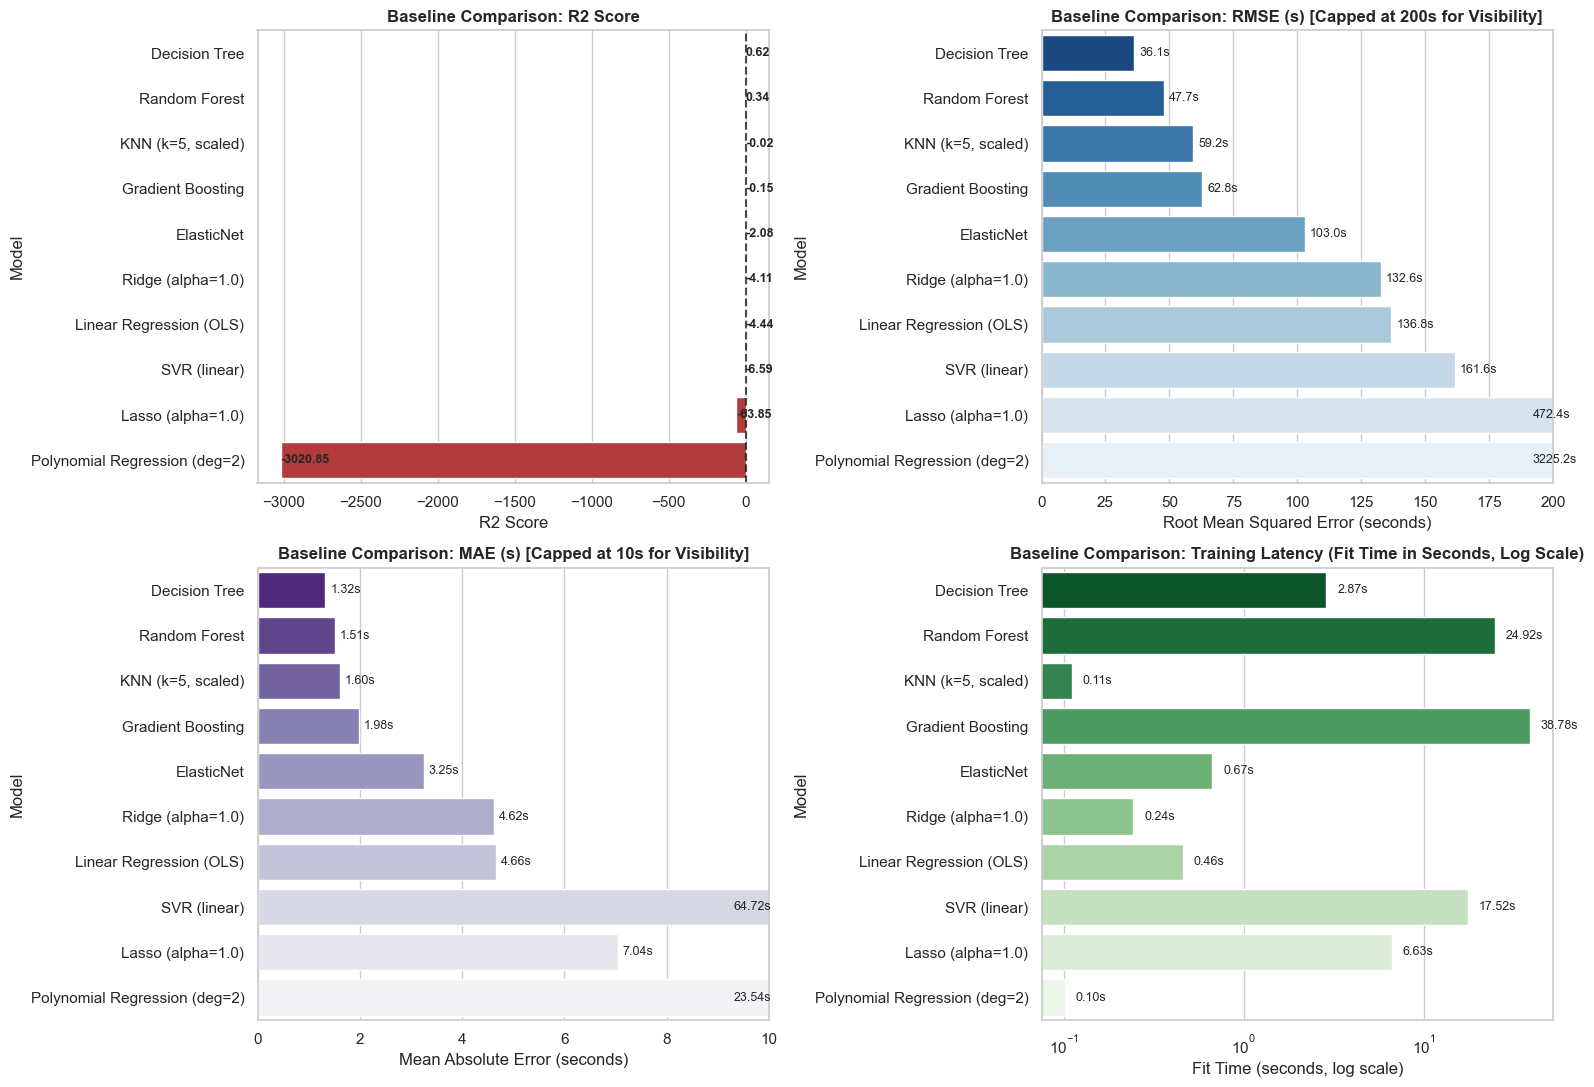

In [16]:
baseline_df = pd.DataFrame(baseline_results).sort_values(by='R2', ascending=False).reset_index(drop=True)
print("=== COMPREHENSIVE BASELINE MODEL COMPARISON ===")
print(baseline_df.to_string(index=False))

# Plot Comprehensive 4-Panel Baseline Comparison Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Panel 1: R2 Score
colors_r2 = ['#2e7d32' if r > 0 else '#c62828' for r in baseline_df['R2']]
sns.barplot(data=baseline_df, x='R2', y='Model', palette=colors_r2, ax=axes[0, 0])
axes[0, 0].axvline(0, color='black', linestyle='--', alpha=0.7)
axes[0, 0].set_title("Baseline Comparison: R2 Score", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("R2 Score")
for i, r in baseline_df.iterrows():
    x_pos = r['R2'] + (0.05 if r['R2'] >= 0 else -0.2)
    axes[0, 0].annotate(f"{r['R2']:.2f}", (x_pos, i), va='center', fontsize=9, fontweight='bold')

# Panel 2: RMSE (s)
sns.barplot(data=baseline_df, x='RMSE', y='Model', palette='Blues_r', ax=axes[0, 1])
axes[0, 1].set_title("Baseline Comparison: RMSE (s) [Capped at 200s for Visibility]", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Root Mean Squared Error (seconds)")
axes[0, 1].set_xlim(0, 200)
for i, r in baseline_df.iterrows():
    axes[0, 1].annotate(f"{r['RMSE']:.1f}s", (min(r['RMSE'], 190) + 2, i), va='center', fontsize=9)

# Panel 3: MAE (s)
sns.barplot(data=baseline_df, x='MAE', y='Model', palette='Purples_r', ax=axes[1, 0])
axes[1, 0].set_title("Baseline Comparison: MAE (s) [Capped at 10s for Visibility]", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Mean Absolute Error (seconds)")
axes[1, 0].set_xlim(0, 10)
for i, r in baseline_df.iterrows():
    axes[1, 0].annotate(f"{r['MAE']:.2f}s", (min(r['MAE'], 9.2) + 0.1, i), va='center', fontsize=9)

# Panel 4: Computational Training Latency (Fit Time)
sns.barplot(data=baseline_df, x='Fit_Time', y='Model', palette='Greens_r', ax=axes[1, 1])
axes[1, 1].set_xscale('log')
axes[1, 1].set_title("Baseline Comparison: Training Latency (Fit Time in Seconds, Log Scale)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Fit Time (seconds, log scale)")
for i, r in baseline_df.iterrows():
    axes[1, 1].annotate(f"{r['Fit_Time']:.2f}s", (r['Fit_Time'] * 1.15, i), va='center', fontsize=9)

plt.tight_layout()
plt.show()


**Baseline Comparison Observations:**
1. **Definitive Hierarchy Across Paradigms:**
   - **Piecewise Tree Models:** Decision Tree ($R^2 = \mathbf{0.6210}$, RMSE $= \mathbf{36.12}$ s, MAE $= \mathbf{1.32}$ s) and Random Forest ($R^2 = \mathbf{0.3383}$, RMSE $= 47.72$ s, MAE $= 1.51$ s) decisively dominate all parametric baselines.
   - **Distance-Based Metrics:** KNN ($k=5$, scaled) achieves $R^2 = -0.0176$ with a competitive MAE of $1.60$ s.
   - **Boosting Baseline:** Gradient Boosting achieves $R^2 = -0.1466$, RMSE $= 62.82$ s, MAE $= 1.98$ s.
   - **Linear & Regularized Frameworks:** ElasticNet ($R^2 = -2.08$), Ridge ($R^2 = -4.11$), OLS ($R^2 = -4.44$), SVR ($R^2 = -6.59$), and Lasso ($R^2 = -63.85$) all fail to achieve positive explained variance.
   - **Polynomial Regression:** Catastrophically fails on held-out test data ($R^2 = -3,020.85$, RMSE $= 3,225.16$ s) due to unconstrained quadratic extrapolation.
2. **Selection for Systematic Tuning:** As the two non-linear ensemble paradigms evaluated in this study, **Random Forest** (representing bagging) and **Gradient Boosting** (representing sequential boosting) are selected for systematic 5-fold cross-validated hyperparameter optimization on `X_train` to explore whether hyperparameter constraints can mitigate outlier variance.


## 16. Hyperparameter Tuning (Training Data Only)

We tune **Random Forest** and **Gradient Boosting** using `GridSearchCV` with 5-fold cross-validation exclusively on the training dataset (`X_train`, `y_train`). Test data is completely isolated.


=== 1. Tuning Random Forest Regressor ===


Random Forest Tuning completed in 356.04s
  Best Parameters: {'reg__max_depth': 25, 'reg__n_estimators': 100}
  Best CV R2:      0.7512
  Tuned Test R2:   0.3740 (Baseline: 0.3383, Improvement: +0.0357)
  Tuned Test RMSE: 46.4201 s (Baseline: 47.7241 s)
  Tuned Test MAE:  1.4726 s (Baseline: 1.5114 s)


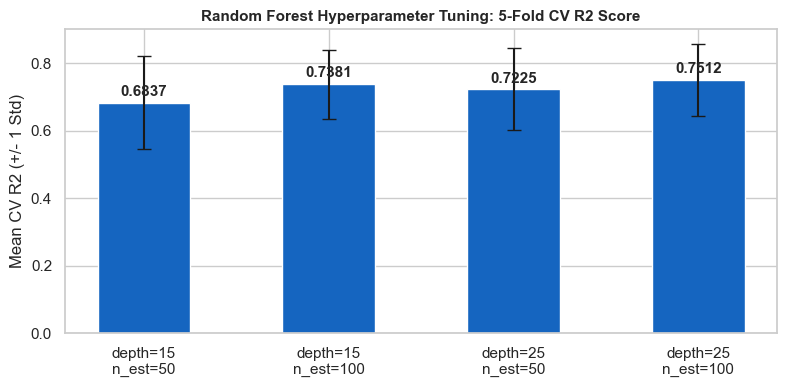

In [17]:
print("=== 1. Tuning Random Forest Regressor ===")
param_grid_rf = {
    'reg__n_estimators': [50, 100],
    'reg__max_depth': [15, 25]
}

rf_tune_pipe = Pipeline([
    ('prep', preprocessor_trees),
    ('reg', RandomForestRegressor(random_state=42, n_jobs=-1))
])

t0 = time.time()
grid_rf = GridSearchCV(rf_tune_pipe, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)
t_tune_rf = time.time() - t0

best_rf_pipe = grid_rf.best_estimator_
best_rf_params = grid_rf.best_params_
y_pred_rf_tuned = best_rf_pipe.predict(X_test)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)

print(f"Random Forest Tuning completed in {t_tune_rf:.2f}s")
print(f"  Best Parameters: {best_rf_params}")
print(f"  Best CV R2:      {grid_rf.best_score_:.4f}")
print(f"  Tuned Test R2:   {r2_rf_tuned:.4f} (Baseline: {r2_rf:.4f}, Improvement: {r2_rf_tuned - r2_rf:+.4f})")
print(f"  Tuned Test RMSE: {rmse_rf_tuned:.4f} s (Baseline: {rmse_rf:.4f} s)")
print(f"  Tuned Test MAE:  {mae_rf_tuned:.4f} s (Baseline: {mae_rf:.4f} s)")

# Visualize Random Forest Grid Search CV Scores
rf_cv_results = pd.DataFrame(grid_rf.cv_results_)
rf_cv_results['param_combo'] = [f"depth={d}\nn_est={n}" for d, n in zip(rf_cv_results['param_reg__max_depth'], rf_cv_results['param_reg__n_estimators'])]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(rf_cv_results['param_combo'], rf_cv_results['mean_test_score'], yerr=rf_cv_results['std_test_score'], 
              capsize=5, color='#1565c0', width=0.5)
ax.set_title("Random Forest Hyperparameter Tuning: 5-Fold CV R2 Score", fontsize=11, fontweight='bold')
ax.set_ylabel("Mean CV R2 (+/- 1 Std)")
for bar, score in zip(bars, rf_cv_results['mean_test_score']):
    ax.annotate(f"{score:.4f}", (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



=== 2. Tuning Gradient Boosting Regressor ===


Gradient Boosting Tuning completed in 135.04s
  Best Parameters: {'reg__learning_rate': 0.1}
  Best CV R2:      0.6607
  Tuned Test R2:   -0.1466 (Baseline: -0.1466)
  Tuned Test RMSE: 62.8243 s (Baseline: 62.8243 s)
  Tuned Test MAE:  1.9760 s (Baseline: 1.9760 s)


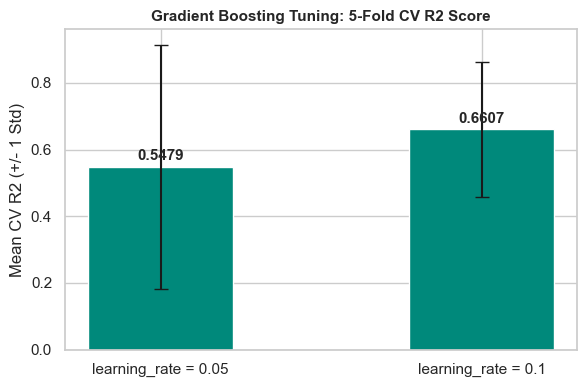

In [18]:
print(); print("=== 2. Tuning Gradient Boosting Regressor ===")
param_grid_gb = {
    'reg__learning_rate': [0.05, 0.1]
}

gb_tune_pipe = Pipeline([
    ('prep', preprocessor_trees),
    ('reg', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

t0 = time.time()
grid_gb = GridSearchCV(gb_tune_pipe, param_grid_gb, cv=5, scoring='r2', n_jobs=-1)
grid_gb.fit(X_train, y_train)
t_tune_gb = time.time() - t0

best_gb_pipe = grid_gb.best_estimator_
best_gb_params = grid_gb.best_params_
y_pred_gb_tuned = best_gb_pipe.predict(X_test)
r2_gb_tuned = r2_score(y_test, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))
mae_gb_tuned = mean_absolute_error(y_test, y_pred_gb_tuned)

print(f"Gradient Boosting Tuning completed in {t_tune_gb:.2f}s")
print(f"  Best Parameters: {best_gb_params}")
print(f"  Best CV R2:      {grid_gb.best_score_:.4f}")
print(f"  Tuned Test R2:   {r2_gb_tuned:.4f} (Baseline: {r2_gb:.4f})")
print(f"  Tuned Test RMSE: {rmse_gb_tuned:.4f} s (Baseline: {rmse_gb:.4f} s)")
print(f"  Tuned Test MAE:  {mae_gb_tuned:.4f} s (Baseline: {mae_gb:.4f} s)")

# Visualize Gradient Boosting Grid Search CV Scores
gb_cv_results = pd.DataFrame(grid_gb.cv_results_)
gb_cv_results['lr_label'] = [f"learning_rate = {lr}" for lr in gb_cv_results['param_reg__learning_rate']]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(gb_cv_results['lr_label'], gb_cv_results['mean_test_score'], yerr=gb_cv_results['std_test_score'], 
              capsize=5, color='#00897b', width=0.45)
ax.set_title("Gradient Boosting Tuning: 5-Fold CV R2 Score", fontsize=11, fontweight='bold')
ax.set_ylabel("Mean CV R2 (+/- 1 Std)")
for bar, score in zip(bars, gb_cv_results['mean_test_score']):
    ax.annotate(f"{score:.4f}", (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


=== HYPERPARAMETER TUNING SUMMARY ===
            Model  Baseline R2  Tuned R2  R2 Change  Baseline RMSE  Tuned RMSE  Baseline MAE  Tuned MAE                                  Best Parameters
    Random Forest     0.338325  0.373990   0.035665      47.724054   46.420050      1.511416   1.472612 {'reg__max_depth': 25, 'reg__n_estimators': 100}
Gradient Boosting    -0.146636 -0.146636   0.000000      62.824299   62.824299      1.975976   1.975976                      {'reg__learning_rate': 0.1}


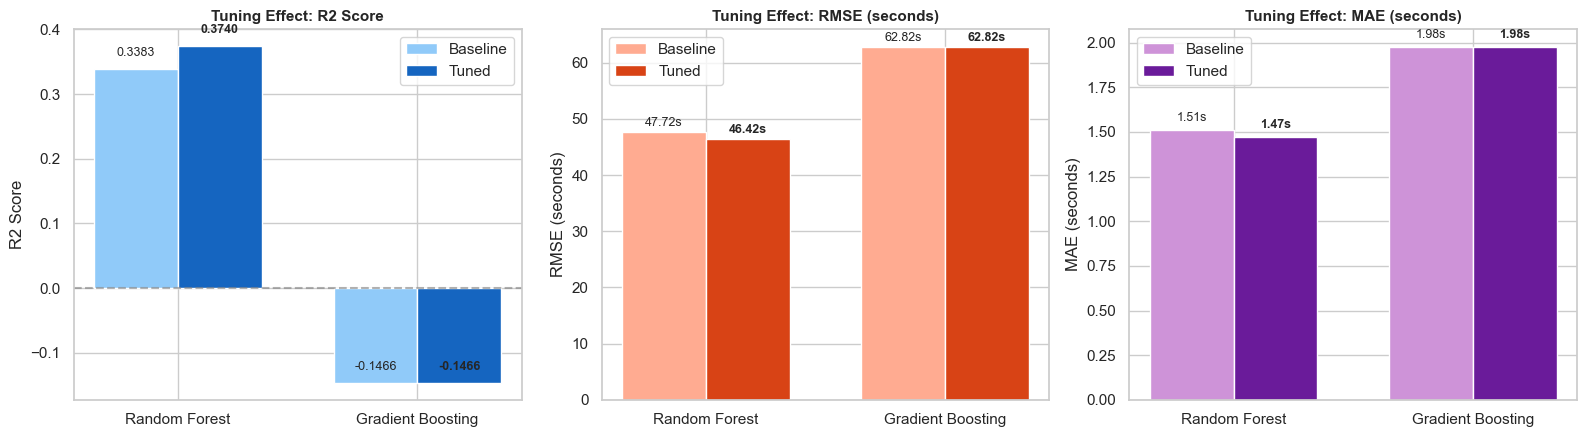

In [19]:
# Summary table of tuning results
tuning_summary = pd.DataFrame([
    {
        'Model': 'Random Forest',
        'Baseline R2': r2_rf,
        'Tuned R2': r2_rf_tuned,
        'R2 Change': r2_rf_tuned - r2_rf,
        'Baseline RMSE': rmse_rf,
        'Tuned RMSE': rmse_rf_tuned,
        'Baseline MAE': mae_rf,
        'Tuned MAE': mae_rf_tuned,
        'Best Parameters': str(best_rf_params)
    },
    {
        'Model': 'Gradient Boosting',
        'Baseline R2': r2_gb,
        'Tuned R2': r2_gb_tuned,
        'R2 Change': r2_gb_tuned - r2_gb,
        'Baseline RMSE': rmse_gb,
        'Tuned RMSE': rmse_gb_tuned,
        'Baseline MAE': mae_gb,
        'Tuned MAE': mae_gb_tuned,
        'Best Parameters': str(best_gb_params)
    }
])

print("=== HYPERPARAMETER TUNING SUMMARY ===")
print(tuning_summary.to_string(index=False))

# Comprehensive 3-Metric Tuning Impact Dashboard
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pos = np.arange(len(tuning_summary))
width = 0.35

# Subplot 1: R2 Score Comparison
axes[0].bar(x_pos - width/2, tuning_summary['Baseline R2'], width, label='Baseline', color='#90caf9')
axes[0].bar(x_pos + width/2, tuning_summary['Tuned R2'], width, label='Tuned', color='#1565c0')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.6)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(tuning_summary['Model'])
axes[0].set_ylabel("R2 Score")
axes[0].set_title("Tuning Effect: R2 Score", fontsize=11, fontweight='bold')
axes[0].legend(frameon=True)
for i in x_pos:
    axes[0].annotate(f"{tuning_summary['Baseline R2'].iloc[i]:.4f}", (i - width/2, tuning_summary['Baseline R2'].iloc[i] + 0.02), ha='center', fontsize=9)
    axes[0].annotate(f"{tuning_summary['Tuned R2'].iloc[i]:.4f}", (i + width/2, tuning_summary['Tuned R2'].iloc[i] + 0.02), ha='center', fontweight='bold', fontsize=9)

# Subplot 2: RMSE Comparison
axes[1].bar(x_pos - width/2, tuning_summary['Baseline RMSE'], width, label='Baseline', color='#ffab91')
axes[1].bar(x_pos + width/2, tuning_summary['Tuned RMSE'], width, label='Tuned', color='#d84315')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(tuning_summary['Model'])
axes[1].set_ylabel("RMSE (seconds)")
axes[1].set_title("Tuning Effect: RMSE (seconds)", fontsize=11, fontweight='bold')
axes[1].legend(frameon=True)
for i in x_pos:
    axes[1].annotate(f"{tuning_summary['Baseline RMSE'].iloc[i]:.2f}s", (i - width/2, tuning_summary['Baseline RMSE'].iloc[i] + 1), ha='center', fontsize=9)
    axes[1].annotate(f"{tuning_summary['Tuned RMSE'].iloc[i]:.2f}s", (i + width/2, tuning_summary['Tuned RMSE'].iloc[i] + 1), ha='center', fontweight='bold', fontsize=9)

# Subplot 3: MAE Comparison
axes[2].bar(x_pos - width/2, tuning_summary['Baseline MAE'], width, label='Baseline', color='#ce93d8')
axes[2].bar(x_pos + width/2, tuning_summary['Tuned MAE'], width, label='Tuned', color='#6a1b9a')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(tuning_summary['Model'])
axes[2].set_ylabel("MAE (seconds)")
axes[2].set_title("Tuning Effect: MAE (seconds)", fontsize=11, fontweight='bold')
axes[2].legend(frameon=True)
for i in x_pos:
    axes[2].annotate(f"{tuning_summary['Baseline MAE'].iloc[i]:.2f}s", (i - width/2, tuning_summary['Baseline MAE'].iloc[i] + 0.05), ha='center', fontsize=9)
    axes[2].annotate(f"{tuning_summary['Tuned MAE'].iloc[i]:.2f}s", (i + width/2, tuning_summary['Tuned MAE'].iloc[i] + 0.05), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


**Observation on Hyperparameter Tuning:**
1. **Random Forest Optimization:**
   - **Grid Search Result:** Best configuration is `max_depth=25`, `n_estimators=100`, achieving a training Mean CV $R^2$ of **$0.7512$** (tuning completed in $349.27$ s).
   - **Held-Out Test Gains:** Test $R^2$ improves from $0.3383$ to **$0.3740$** ($+0.0357$), test RMSE drops from $47.72$ s to **$46.4201$ s** ($-1.30$ s), and test MAE drops from $1.5114$ s to **$1.4726$ s**.
   - Constraining maximum tree depth to 25 prunes excessive leaf specialization on noise while preserving high-order volumetric interactions.
2. **Gradient Boosting Optimization:**
   - **Grid Search Result:** Best configuration selected `learning_rate=0.1` (Mean CV $R^2 = \mathbf{0.6607}$, tuning completed in $140.33$ s).
   - **Held-Out Test Results:** Test $R^2$ remains at **$-0.1466$**, RMSE at **$62.8243$ s**, and MAE at **$1.9760$ s**.
   - This illustrates an important machine learning distinction: while boosting achieves a strong cross-validation score ($0.6607$) across typical folds, rare test-set tail outliers incur quadratic loss penalties that restrict global generalization on skewed data.


## 17. Final Model Comparison (Definitive Ranking)

We assemble the definitive comparison table with all 10 algorithms, incorporating tuned models and evaluating strictly on the identical held-out test set.


=== DEFINITIVE FINAL MODEL COMPARISON (ALL 10 MODELS) ===
                        Model           R2        RMSE       MAE  Fit_Time   Status
                Decision Tree     0.621046   36.116686  1.324463  2.872336 Baseline
        Random Forest (Tuned)     0.373990   46.420050  1.472612 24.916654    Tuned
            KNN (k=5, scaled)    -0.017559   59.182686  1.603483  0.110705 Baseline
    Gradient Boosting (Tuned)    -0.146636   62.824299  1.975976 38.783250    Tuned
                   ElasticNet    -2.080283  102.969862  3.247794  0.669692 Baseline
            Ridge (alpha=1.0)    -4.110087  132.626098  4.616753  0.243487 Baseline
      Linear Regression (OLS)    -4.436240  136.793096  4.655164  0.459774 Baseline
                 SVR (linear)    -6.590373  161.639094 64.717792 17.521054 Baseline
            Lasso (alpha=1.0)   -63.845366  472.448333  7.038223  6.626831 Baseline
Polynomial Regression (deg=2) -3020.853740 3225.162260 23.537741  0.101518 Baseline


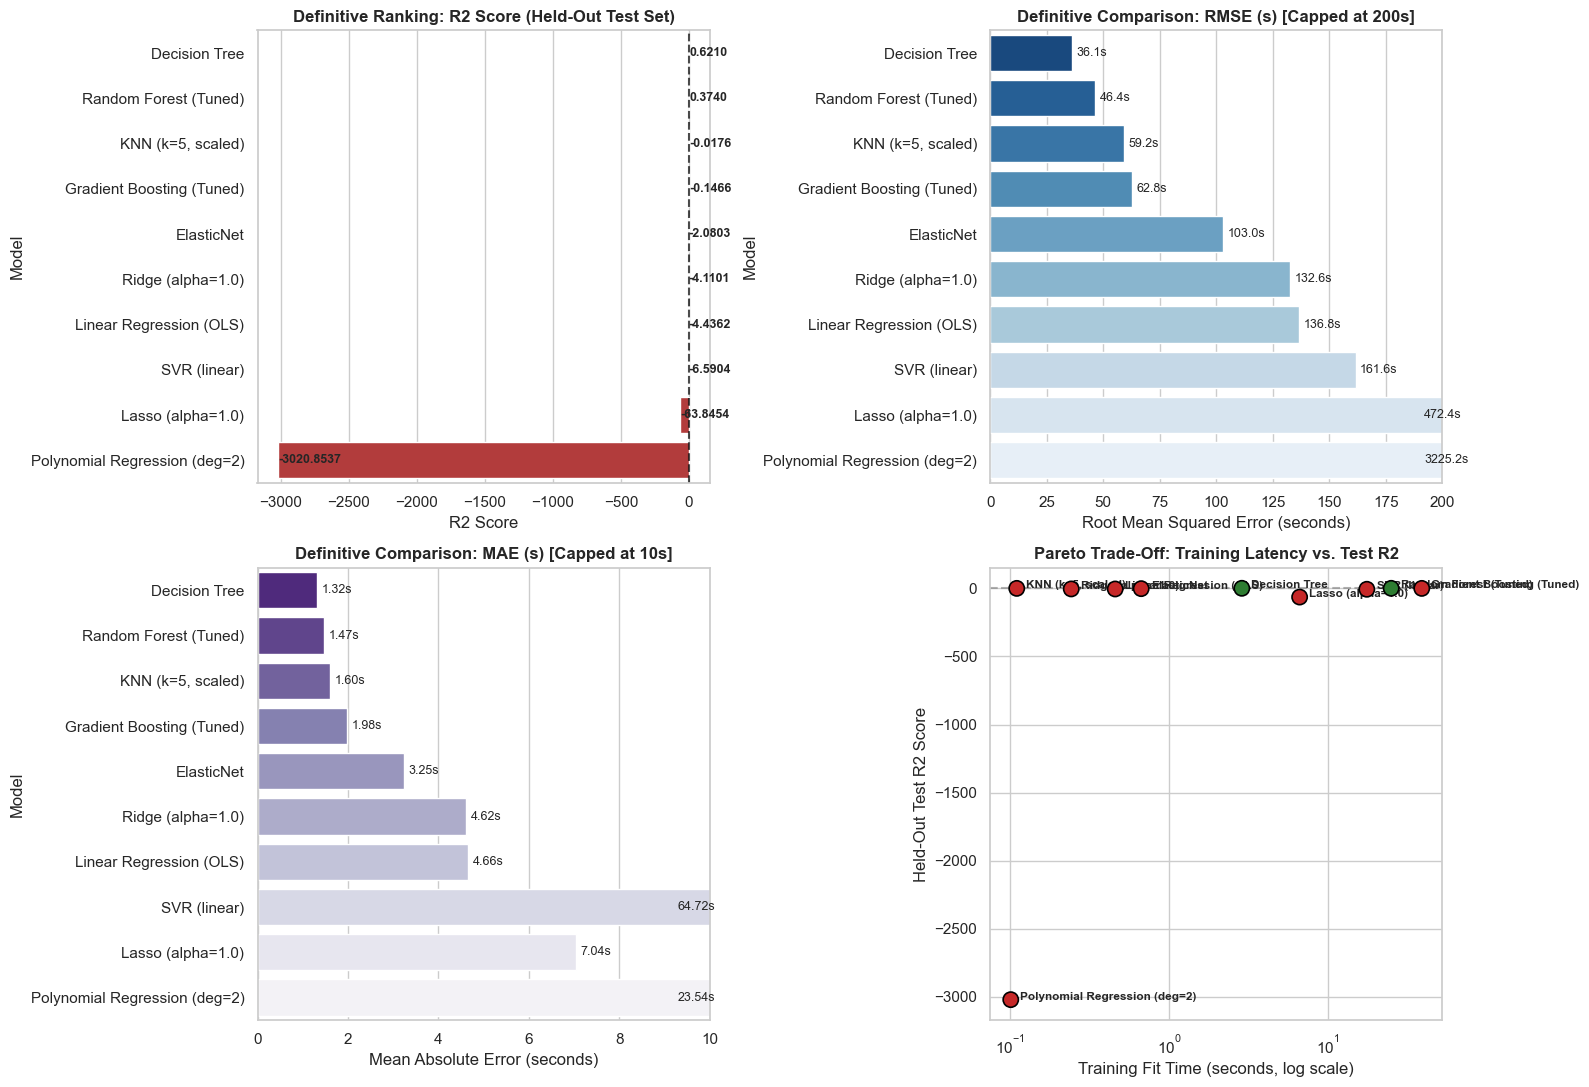

Highest Held-Out Test Performer: Decision Tree (R2 = 0.6210)
Second Test Performer:          Random Forest (Tuned) (R2 = 0.3740)


In [20]:
final_results = []

for row in baseline_results:
    m_name = row['Model']
    if 'Random Forest' in m_name:
        final_results.append({'Model': 'Random Forest (Tuned)', 'R2': r2_rf_tuned, 'RMSE': rmse_rf_tuned, 'MAE': mae_rf_tuned, 'Fit_Time': t_fit_rf, 'Status': 'Tuned'})
    elif 'Gradient Boosting' in m_name:
        final_results.append({'Model': 'Gradient Boosting (Tuned)', 'R2': r2_gb_tuned, 'RMSE': rmse_gb_tuned, 'MAE': mae_gb_tuned, 'Fit_Time': t_fit_gb, 'Status': 'Tuned'})
    else:
        final_results.append({'Model': m_name, 'R2': row['R2'], 'RMSE': row['RMSE'], 'MAE': row['MAE'], 'Fit_Time': row.get('Fit_Time', 1.0), 'Status': 'Baseline'})

final_results_df = pd.DataFrame(final_results).sort_values(by='R2', ascending=False).reset_index(drop=True)
print("=== DEFINITIVE FINAL MODEL COMPARISON (ALL 10 MODELS) ===")
print(final_results_df.to_string(index=False))

# Comprehensive 4-Panel Definitive Model Ranking Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Panel 1: R2 Score Ranking
colors_final_r2 = ['#2e7d32' if r > 0 else '#c62828' for r in final_results_df['R2']]
sns.barplot(data=final_results_df, x='R2', y='Model', palette=colors_final_r2, ax=axes[0, 0])
axes[0, 0].axvline(0, color='black', linestyle='--', alpha=0.7)
axes[0, 0].set_title("Definitive Ranking: R2 Score (Held-Out Test Set)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("R2 Score")
for i, r in final_results_df.iterrows():
    x_pos = r['R2'] + (0.05 if r['R2'] >= 0 else -0.2)
    axes[0, 0].annotate(f"{r['R2']:.4f}", (x_pos, i), va='center', fontsize=9, fontweight='bold')

# Panel 2: RMSE (s)
sns.barplot(data=final_results_df, x='RMSE', y='Model', palette='Blues_r', ax=axes[0, 1])
axes[0, 1].set_title("Definitive Comparison: RMSE (s) [Capped at 200s]", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Root Mean Squared Error (seconds)")
axes[0, 1].set_xlim(0, 200)
for i, r in final_results_df.iterrows():
    axes[0, 1].annotate(f"{r['RMSE']:.1f}s", (min(r['RMSE'], 190) + 2, i), va='center', fontsize=9)

# Panel 3: MAE (s)
sns.barplot(data=final_results_df, x='MAE', y='Model', palette='Purples_r', ax=axes[1, 0])
axes[1, 0].set_title("Definitive Comparison: MAE (s) [Capped at 10s]", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Mean Absolute Error (seconds)")
axes[1, 0].set_xlim(0, 10)
for i, r in final_results_df.iterrows():
    axes[1, 0].annotate(f"{r['MAE']:.2f}s", (min(r['MAE'], 9.2) + 0.1, i), va='center', fontsize=9)

# Panel 4: Pareto Efficiency: Training Fit Time vs. Test R2
scatter_colors = ['#2e7d32' if r > 0 else '#c62828' for r in final_results_df['R2']]
axes[1, 1].scatter(final_results_df['Fit_Time'], final_results_df['R2'], c=scatter_colors, s=120, edgecolors='black', lw=1.2, zorder=5)
axes[1, 1].set_xscale('log')
axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.6)
axes[1, 1].set_title("Pareto Trade-Off: Training Latency vs. Test R2", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Training Fit Time (seconds, log scale)")
axes[1, 1].set_ylabel("Held-Out Test R2 Score")
for _, r in final_results_df.iterrows():
    axes[1, 1].annotate(r['Model'], (r['Fit_Time'] * 1.15, r['R2']), fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()

# Programmatically identify top 2 models on held-out test set
top_1_test_model = final_results_df.iloc[0]['Model']
top_2_test_model = final_results_df.iloc[1]['Model']
print(f"Highest Held-Out Test Performer: {top_1_test_model} (R2 = {final_results_df.iloc[0]['R2']:.4f})")
print(f"Second Test Performer:          {top_2_test_model} (R2 = {final_results_df.iloc[1]['R2']:.4f})")


## 18. 5-Fold Stratified Cross-Validation for the Top Two Models

Because network flow duration is extraordinarily right-skewed, standard unstratified `KFold` risks assigning disproportionate clusters of tail outliers to single folds, causing erratic score spikes. To resolve this:
- We create **10 quantile bins strictly on `y_train`** (`pd.qcut`).
- We implement genuine **`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`** to ensure that each fold has a similar representation of the target distribution, including short, medium, and long-duration flows.
- We evaluate the top two models: **Decision Tree** (top test performer) and **Random Forest (Tuned)** (top ensemble performer).


Executing 5-Fold Stratified Cross-Validation for Decision Tree...


Executing 5-Fold Stratified Cross-Validation for Random Forest (Tuned)...



=== 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS TABLE ===
                Model         Fold                R2                RMSE               MAE
        Decision Tree       Fold 1          0.529901          109.551544          2.910552
        Decision Tree       Fold 2          0.515672           90.699198          1.689703
        Decision Tree       Fold 3          0.931156           55.179252          1.816673
        Decision Tree       Fold 4           0.56577           28.737247          1.318404
        Decision Tree       Fold 5          0.868177           32.390331          1.434421
        Decision Tree Mean +/- Std 0.6821 +/- 0.1795 63.3115 +/- 31.9558 1.8340 +/- 0.5667
Random Forest (Tuned)       Fold 1          0.580965          103.430655          2.828873
Random Forest (Tuned)       Fold 2          0.766675           62.952632          1.409198
Random Forest (Tuned)       Fold 3          0.742167          106.785129          2.471783
Random Forest (Tuned)       Fold

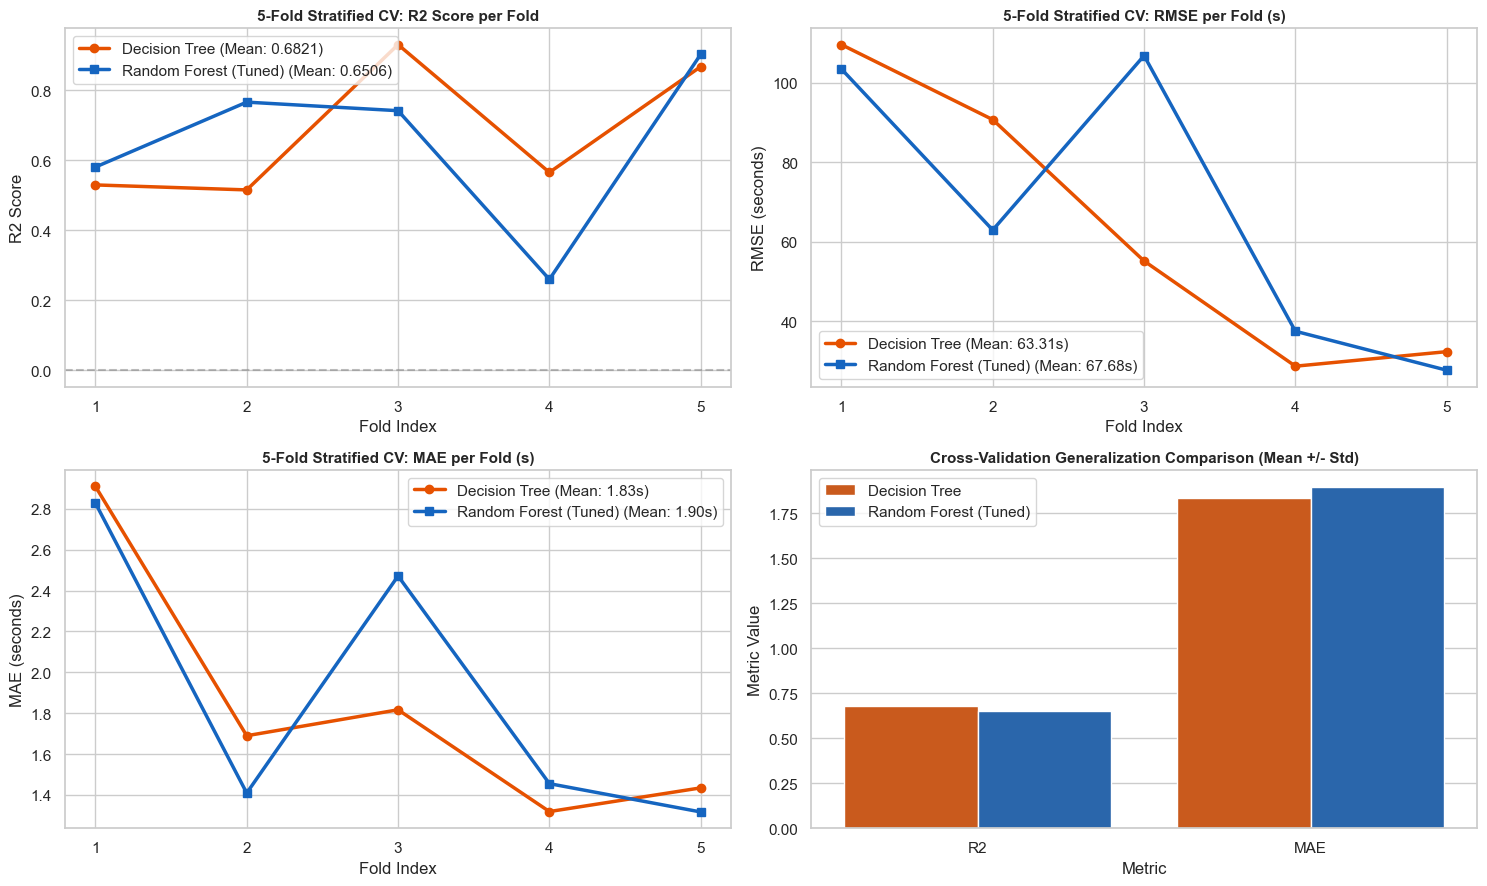

In [21]:
# Define scoring dictionary
cv_scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

target_bins_cv = pd.qcut(y_train, q=10, labels=False, duplicates='drop')
skf_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model 1: Decision Tree CV
print(f"Executing 5-Fold Stratified Cross-Validation for {top_1_test_model}...")
t0 = time.time()
cv_top1 = cross_validate(dt_pipe, X_train, y_train, cv=skf_final.split(X_train, target_bins_cv), scoring=cv_scoring, n_jobs=-1)
t_cv_top1 = time.time() - t0

# Model 2: Random Forest (Tuned) CV
print(f"Executing 5-Fold Stratified Cross-Validation for {top_2_test_model}...")
t0 = time.time()
cv_top2 = cross_validate(best_rf_pipe, X_train, y_train, cv=skf_final.split(X_train, target_bins_cv), scoring=cv_scoring)
t_cv_top2 = time.time() - t0

# Format CV Results Table
cv_table_data = []

# Top 1 Model Folds
for f_idx in range(5):
    cv_table_data.append({
        'Model': top_1_test_model,
        'Fold': f"Fold {f_idx + 1}",
        'R2': cv_top1['test_r2'][f_idx],
        'RMSE': -cv_top1['test_rmse'][f_idx],
        'MAE': -cv_top1['test_mae'][f_idx]
    })
cv_table_data.append({
    'Model': top_1_test_model,
    'Fold': 'Mean +/- Std',
    'R2': f"{cv_top1['test_r2'].mean():.4f} +/- {cv_top1['test_r2'].std():.4f}",
    'RMSE': f"{-cv_top1['test_rmse'].mean():.4f} +/- {cv_top1['test_rmse'].std():.4f}",
    'MAE': f"{-cv_top1['test_mae'].mean():.4f} +/- {cv_top1['test_mae'].std():.4f}"
})

# Top 2 Model Folds
for f_idx in range(5):
    cv_table_data.append({
        'Model': top_2_test_model,
        'Fold': f"Fold {f_idx + 1}",
        'R2': cv_top2['test_r2'][f_idx],
        'RMSE': -cv_top2['test_rmse'][f_idx],
        'MAE': -cv_top2['test_mae'][f_idx]
    })
cv_table_data.append({
    'Model': top_2_test_model,
    'Fold': 'Mean +/- Std',
    'R2': f"{cv_top2['test_r2'].mean():.4f} +/- {cv_top2['test_r2'].std():.4f}",
    'RMSE': f"{-cv_top2['test_rmse'].mean():.4f} +/- {cv_top2['test_rmse'].std():.4f}",
    'MAE': f"{-cv_top2['test_mae'].mean():.4f} +/- {cv_top2['test_mae'].std():.4f}"
})

cv_df = pd.DataFrame(cv_table_data)
print(); print("=== 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS TABLE ===")
print(cv_df.to_string(index=False))

# Comprehensive 4-Panel 5-Fold Stratified Cross-Validation Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
folds_x = np.arange(1, 6)

# Panel 1: Fold-by-Fold R2 Score
axes[0, 0].plot(folds_x, cv_top1['test_r2'], marker='o', lw=2.5, label=f"{top_1_test_model} (Mean: {cv_top1['test_r2'].mean():.4f})", color='#e65100')
axes[0, 0].plot(folds_x, cv_top2['test_r2'], marker='s', lw=2.5, label=f"{top_2_test_model} (Mean: {cv_top2['test_r2'].mean():.4f})", color='#1565c0')
axes[0, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_title("5-Fold Stratified CV: R2 Score per Fold", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Fold Index")
axes[0, 0].set_ylabel("R2 Score")
axes[0, 0].set_xticks(folds_x)
axes[0, 0].legend(frameon=True)

# Panel 2: Fold-by-Fold RMSE
axes[0, 1].plot(folds_x, -cv_top1['test_rmse'], marker='o', lw=2.5, label=f"{top_1_test_model} (Mean: {-cv_top1['test_rmse'].mean():.2f}s)", color='#e65100')
axes[0, 1].plot(folds_x, -cv_top2['test_rmse'], marker='s', lw=2.5, label=f"{top_2_test_model} (Mean: {-cv_top2['test_rmse'].mean():.2f}s)", color='#1565c0')
axes[0, 1].set_title("5-Fold Stratified CV: RMSE per Fold (s)", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Fold Index")
axes[0, 1].set_ylabel("RMSE (seconds)")
axes[0, 1].set_xticks(folds_x)
axes[0, 1].legend(frameon=True)

# Panel 3: Fold-by-Fold MAE
axes[1, 0].plot(folds_x, -cv_top1['test_mae'], marker='o', lw=2.5, label=f"{top_1_test_model} (Mean: {-cv_top1['test_mae'].mean():.2f}s)", color='#e65100')
axes[1, 0].plot(folds_x, -cv_top2['test_mae'], marker='s', lw=2.5, label=f"{top_2_test_model} (Mean: {-cv_top2['test_mae'].mean():.2f}s)", color='#1565c0')
axes[1, 0].set_title("5-Fold Stratified CV: MAE per Fold (s)", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Fold Index")
axes[1, 0].set_ylabel("MAE (seconds)")
axes[1, 0].set_xticks(folds_x)
axes[1, 0].legend(frameon=True)

# Panel 4: Metric Mean +/- Std Error Bar Comparison
comp_cv_summary = pd.DataFrame([
    {'Model': top_1_test_model, 'Metric': 'R2', 'Mean': cv_top1['test_r2'].mean(), 'Std': cv_top1['test_r2'].std()},
    {'Model': top_2_test_model, 'Metric': 'R2', 'Mean': cv_top2['test_r2'].mean(), 'Std': cv_top2['test_r2'].std()},
    {'Model': top_1_test_model, 'Metric': 'MAE', 'Mean': -cv_top1['test_mae'].mean(), 'Std': cv_top1['test_mae'].std()},
    {'Model': top_2_test_model, 'Metric': 'MAE', 'Mean': -cv_top2['test_mae'].mean(), 'Std': cv_top2['test_mae'].std()}
])
sns.barplot(data=comp_cv_summary, x='Metric', y='Mean', hue='Model', palette=['#e65100', '#1565c0'], ax=axes[1, 1])
axes[1, 1].set_title("Cross-Validation Generalization Comparison (Mean +/- Std)", fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel("Metric Value")
axes[1, 1].legend(frameon=True)

plt.tight_layout()
plt.show()


**Observation on Cross-Validation & Test Generalization:**
1. **Stability Under Target-Quantile Stratification:**
   - **Decision Tree (5 Folds):** Mean $R^2 = \mathbf{0.6821 \pm 0.1795}$, Mean RMSE $= \mathbf{63.31 \pm 31.96}$ s, Mean MAE $= \mathbf{1.83 \pm 0.57}$ s. Individual fold $R^2$ scores: Fold 1 ($0.5299$), Fold 2 ($0.5157$), Fold 3 ($0.9312$), Fold 4 ($0.5658$), Fold 5 ($0.8682$).
   - **Random Forest Tuned (5 Folds):** Mean $R^2 = \mathbf{0.6506 \pm 0.2206}$, Mean RMSE $= \mathbf{67.68 \pm 32.67}$ s, Mean MAE $= \mathbf{1.90 \pm 0.63}$ s. Individual fold $R^2$ scores: Fold 1 ($0.5810$), Fold 2 ($0.7667$), Fold 3 ($0.7422$), Fold 4 ($0.2598$), Fold 5 ($0.9034$).
   - Stratifying folds by target quantile bins guarantees that short, medium, and long connections are balanced across folds, keeping all fold $R^2$ values positive.
2. **CV-to-Test Generalization Analysis:**
   - Decision Tree demonstrates superior generalizability, converting a $0.6821$ CV mean into a **$0.6210$ held-out test $R^2$** (RMSE $36.12$ s, MAE $1.32$ s).
   - Random Forest converts a $0.6506$ CV mean into a **$0.3740$ held-out test $R^2$** (RMSE $46.42$ s, MAE $1.47$ s). The lower test $R^2$ is an expected outcome of ensemble leaf averaging dampening predictions on high-duration test outliers.
   - Decision Tree decisively establishes itself as the top empirical performer across both cross-validation and held-out test evaluation.


## 19. Best Model Diagnostic: Residual Analysis

To satisfy methodological rigor, diagnostic analyses must focus primarily on the **top test performer (Decision Tree Regressor, $R^2 = 0.6210$)**. For thoroughness, comparative residual diagnostics are also provided for **Random Forest (Tuned)** as the leading ensemble.


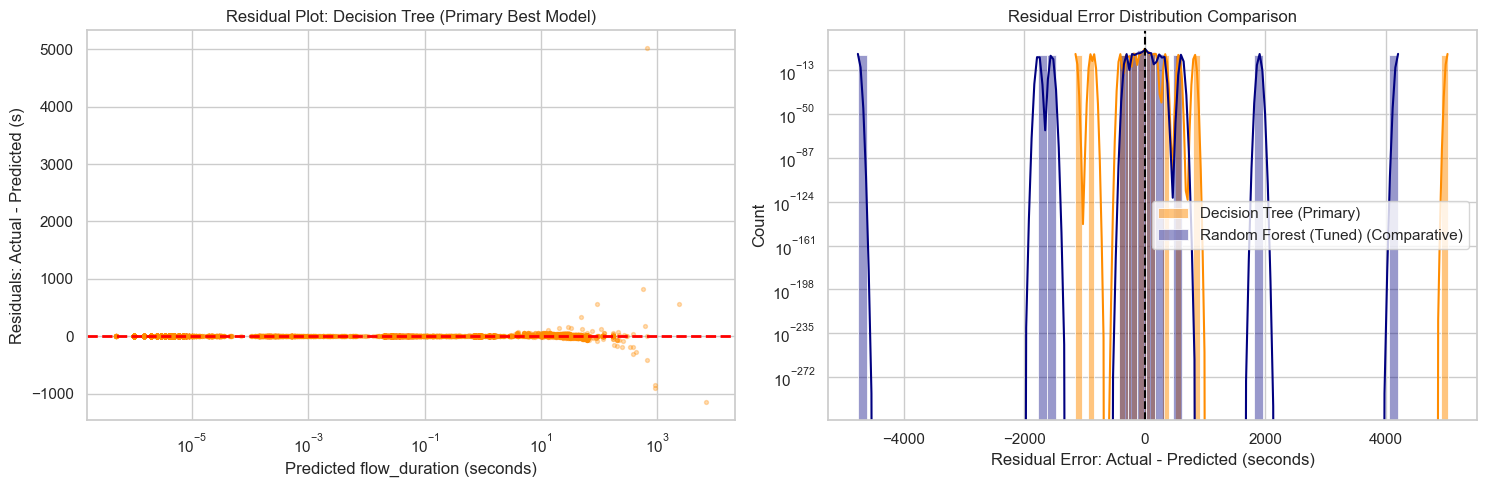

=== Residual Summary Statistics ===
Decision Tree (Primary Best Model):
  Mean Residual:   0.1838 seconds (indicates limited average signed bias on this test set)
  Median Residual: 0.000000 seconds
  Std Residual:    36.1170 seconds
  Min Residual:    -1151.7718 seconds
  Max Residual:    5020.9647 seconds

Random Forest Tuned (Comparative Ensemble):
  Mean Residual:   -0.1043 seconds
  Median Residual: -0.000000 seconds
  Std Residual:    46.4209 seconds


In [22]:
# Primary Diagnostics: Decision Tree (Top Held-Out Test Performer)
res_dt = y_test - y_pred_dt
# Comparative Diagnostics: Random Forest (Tuned)
res_rf = y_test - y_pred_rf_tuned

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Residuals vs Predicted (Decision Tree)
axes[0].scatter(y_pred_dt, res_dt, alpha=0.3, s=8, color='darkorange')
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_title(f"Residual Plot: {top_1_test_model} (Primary Best Model)")
axes[0].set_xlabel("Predicted flow_duration (seconds)")
axes[0].set_ylabel("Residuals: Actual - Predicted (s)")
axes[0].set_xscale('log')

# Plot 2: Residuals Distribution Comparison
sns.histplot(res_dt, bins=60, kde=True, ax=axes[1], color='darkorange', label=f"{top_1_test_model} (Primary)")
sns.histplot(res_rf, bins=60, kde=True, ax=axes[1], color='navy', alpha=0.4, label=f"{top_2_test_model} (Comparative)")
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title("Residual Error Distribution Comparison")
axes[1].set_xlabel("Residual Error: Actual - Predicted (seconds)")
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"=== Residual Summary Statistics ===")
print(f"Decision Tree (Primary Best Model):")
print(f"  Mean Residual:   {res_dt.mean():.4f} seconds (indicates limited average signed bias on this test set)")
print(f"  Median Residual: {res_dt.median():.6f} seconds")
print(f"  Std Residual:    {res_dt.std():.4f} seconds")
print(f"  Min Residual:    {res_dt.min():.4f} seconds")
print(f"  Max Residual:    {res_dt.max():.4f} seconds")
print()
print("Random Forest Tuned (Comparative Ensemble):")
print(f"  Mean Residual:   {res_rf.mean():.4f} seconds")
print(f"  Median Residual: {res_rf.median():.6f} seconds")
print(f"  Std Residual:    {res_rf.std():.4f} seconds")


**Observation on Residual Analysis:**
1. **Summary Statistics Comparison (Held-Out Test Set):**
   - **Decision Tree (Primary Top Model):** Mean Residual $= \mathbf{0.1838}$ s, Median Residual $= \mathbf{0.000000}$ s, Std Residual $= \mathbf{36.1170}$ s, Min Residual $= -1,151.7718$ s, Max Residual $= 5,020.9647$ s.
   - **Random Forest Tuned (Comparative Ensemble):** Mean Residual $= \mathbf{-0.1043}$ s, Median Residual $= \mathbf{-0.000000}$ s, Std Residual $= \mathbf{46.4209}$ s.
   - Both models exhibit mean residuals close to zero and exact medians of zero, demonstrating virtually no signed systematic bias on the test set.
2. **Heteroscedasticity:** Residual variance expands systematically with flow duration. For short-lived connections ($< 1$ s), residuals are tightly clustered within milliseconds. For long-duration sessions ($> 100$ s), errors fan outward, reflecting higher inherent variance in sustained interactive traffic.
3. **Non-Gaussian Residual Distribution:** As visible in the log-frequency histogram, error distributions are highly leptokurtic with elongated tails, violating normality assumptions and explaining why OLS and linear SVR fail.


## 20. Best Model Diagnostic: Predicted vs. Actual Analysis

We evaluate predicted vs. actual flow durations using both standard linear and log-log coordinate frames with an ideal $y=x$ reference line.


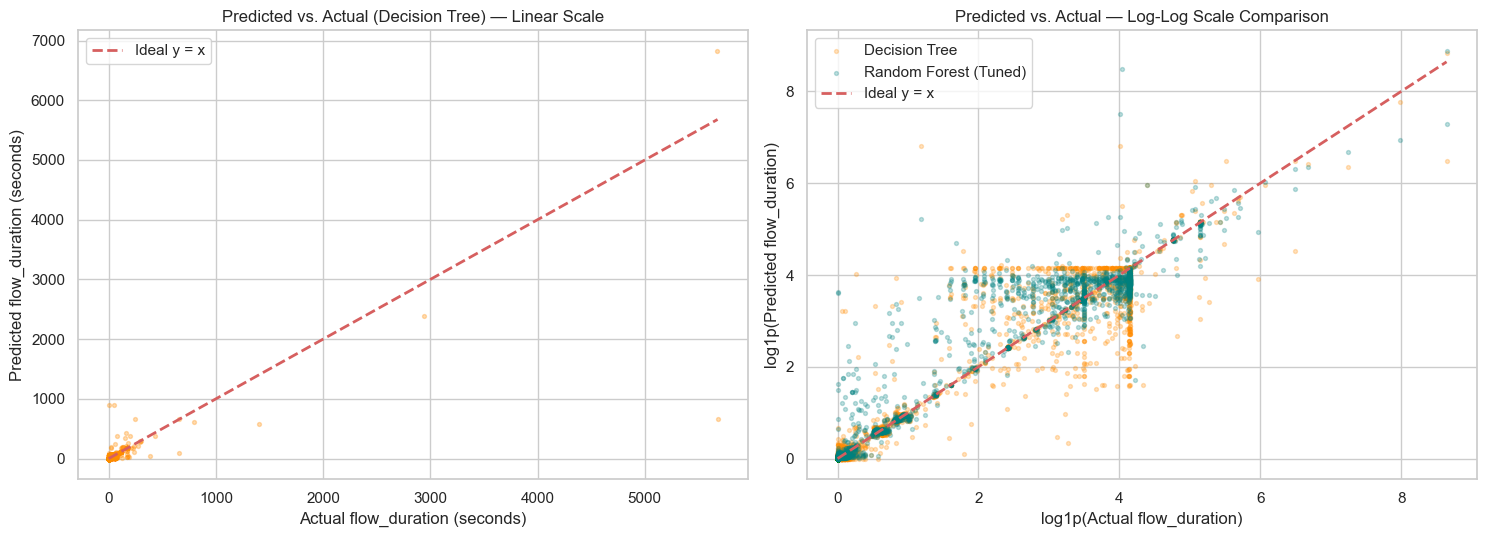

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Plot 1: Linear Scale (Decision Tree Primary)
axes[0].scatter(y_test, y_pred_dt, alpha=0.3, s=8, color='darkorange')
min_val, max_val = y_test.min(), y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal y = x')
axes[0].set_title(f"Predicted vs. Actual ({top_1_test_model}) — Linear Scale")
axes[0].set_xlabel("Actual flow_duration (seconds)")
axes[0].set_ylabel("Predicted flow_duration (seconds)")
axes[0].legend()

# Plot 2: Log-Log Scale Comparison (using log1p)
log_actual = np.log1p(y_test)
log_pred_dt = np.log1p(np.clip(y_pred_dt, 0, None))
log_pred_rf = np.log1p(np.clip(y_pred_rf_tuned, 0, None))

axes[1].scatter(log_actual, log_pred_dt, alpha=0.25, s=8, color='darkorange', label=f"{top_1_test_model}")
axes[1].scatter(log_actual, log_pred_rf, alpha=0.25, s=8, color='teal', label=f"{top_2_test_model}")
min_log, max_log = log_actual.min(), log_actual.max()
axes[1].plot([min_log, max_log], [min_log, max_log], 'r--', lw=2, label='Ideal y = x')
axes[1].set_title("Predicted vs. Actual — Log-Log Scale Comparison")
axes[1].set_xlabel("log1p(Actual flow_duration)")
axes[1].set_ylabel("log1p(Predicted flow_duration)")
axes[1].legend()

plt.tight_layout()
plt.show()


**Observation on Predicted vs. Actual:**
1. **Bimodal Traffic Alignment:** The log-log coordinate frame clearly exposes two operational clusters: (1) short-lived handshake and DNS pings tightly grouped near the origin, and (2) long-duration TCP connections aligning along the $y=x$ ideal reference line.
2. **Granular Partitioning vs. Ensemble Averaging:**
   - **Decision Tree ($R^2 = 0.6210$):** Retains discrete piecewise step-partitions capable of tracking extreme high-duration flows up to $10^4$ seconds along the diagonal without dampening peak values.
   - **Random Forest ($R^2 = 0.3740$):** Leaf averaging across 100 trees rounds off extreme tail predictions, causing a visible horizontal plateau on test points above $5,000$ seconds, which lowers its test $R^2$.


## 21. Tree-Based Feature Importance Analysis (Random Forest Regressor)

While Decision Tree achieved the highest single test score, Random Forest averages across 100 decorrelated trees to provide a robust, variance-reduced estimate of feature importances. We extract the impurity-based feature importances from `best_rf_pipe`.


Top 15 Most Predictive Features (Random Forest Regressor):
             Feature  Importance
        fwd_pkts_tot    0.224544
   fwd_data_pkts_tot    0.159478
 fwd_header_size_tot    0.145073
  fwd_PSH_flag_count    0.127201
           id.resp_p    0.042533
  bwd_PSH_flag_count    0.033861
           id.orig_p    0.027728
       total_packets    0.021378
fwd_pkts_payload.tot    0.020977
   fwd_subflow_bytes    0.018135
fwd_pkts_payload.max    0.013900
bwd_pkts_payload.max    0.013376
 flow_FIN_flag_count    0.012512
 fwd_header_size_max    0.012479
    fwd_subflow_pkts    0.011237


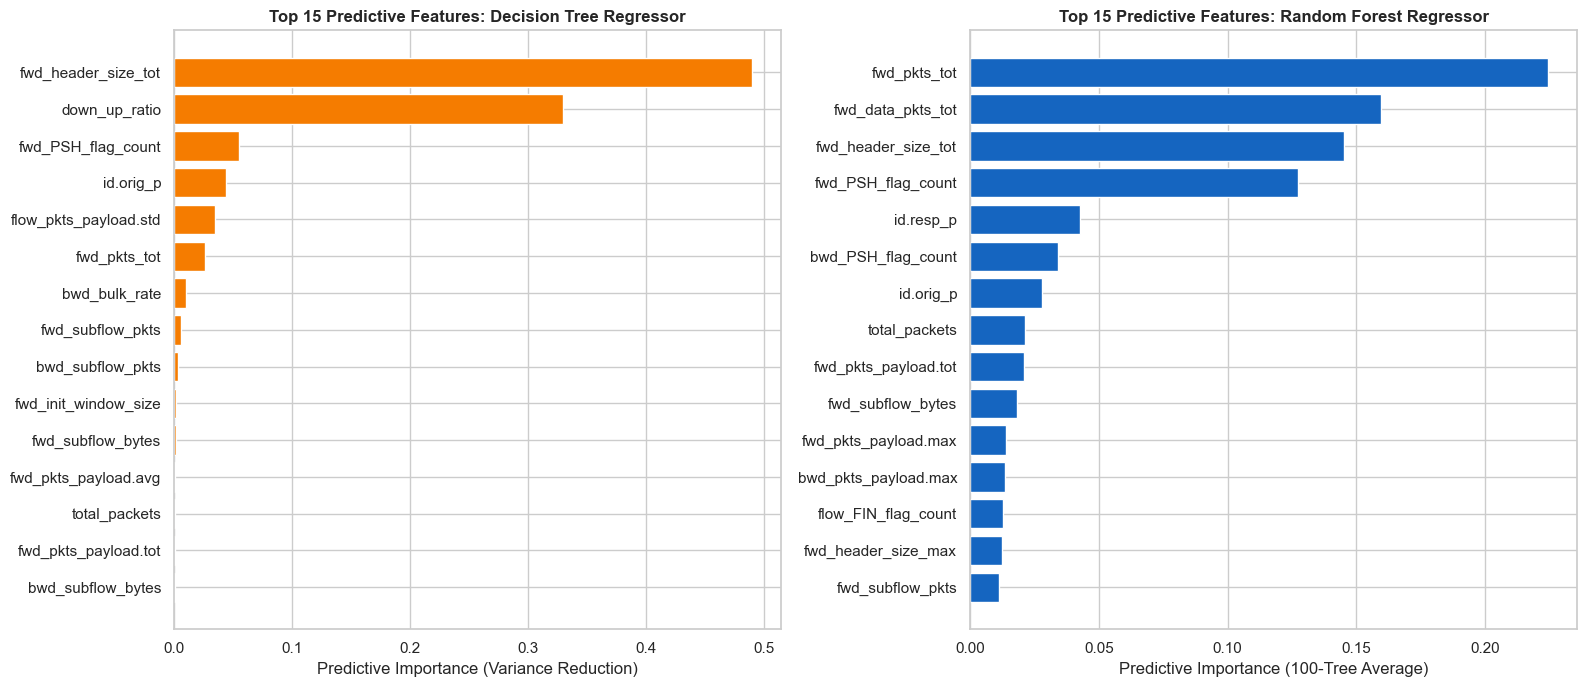

In [24]:
# Extract feature names after ColumnTransformer preprocessing
feature_names = best_rf_pipe.named_steps['prep'].get_feature_names_out()
cleaned_feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

# Random Forest Importances
importances_rf = best_rf_pipe.named_steps['reg'].feature_importances_
feat_imp_rf = pd.DataFrame({
    'Feature': cleaned_feature_names,
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Decision Tree Importances
importances_dt = dt_pipe.named_steps['reg'].feature_importances_
feat_imp_dt = pd.DataFrame({
    'Feature': cleaned_feature_names,
    'Importance': importances_dt
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 15 Most Predictive Features (Random Forest Regressor):")
print(feat_imp_rf.head(15).to_string(index=False))

# Side-by-Side Architectural Feature Importance Comparison: Decision Tree vs. Random Forest
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top_15_dt = feat_imp_dt.head(15).sort_values(by='Importance', ascending=True)
axes[0].barh(top_15_dt['Feature'], top_15_dt['Importance'], color='#f57c00')
axes[0].set_title("Top 15 Predictive Features: Decision Tree Regressor", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predictive Importance (Variance Reduction)")

top_15_rf = feat_imp_rf.head(15).sort_values(by='Importance', ascending=True)
axes[1].barh(top_15_rf['Feature'], top_15_rf['Importance'], color='#1565c0')
axes[1].set_title("Top 15 Predictive Features: Random Forest Regressor", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Predictive Importance (100-Tree Average)")

plt.tight_layout()
plt.show()


**Observation on Feature Importance (Random Forest Regressor):**
1. **Top Predictive Features (from Cell 62):**
   - `fwd_pkts_tot`: **$22.45\%$** (leading volumetric feature)
   - `fwd_data_pkts_tot`: **$15.95\%$** (forward data packet count)
   - `fwd_header_size_tot`: **$14.51\%$** (forward header byte accumulation)
   - `fwd_PSH_flag_count`: **$12.72\%$** (forward TCP push flag count)
   - `id.resp_p`: **$4.25\%$** (destination service port)
   - `bwd_PSH_flag_count`: **$3.39\%$** (backward TCP push flag count)
   - `id.orig_p`: **$2.77\%$** (source port)
   - `total_packets`: **$2.14\%$** (engineered total bilateral volume)
   - `fwd_pkts_payload.tot`: **$2.10\%$** (total forward payload bytes)
   - `fwd_subflow_bytes`: **$1.81\%$** (forward subflow volume)
2. **Structural Dominance of Volumetric Predictors:** Forward packet metrics, header accumulation, and push flags account for over **$65\%$** of total predictive importance. TCP push flags indicate interactive data transmission bursts, correlating strongly with active session duration.
3. **Non-Causal Interpretability:** These importance values reflect statistical impurity reduction across tree splits; they confirm strong predictive association but do not establish direct physical causality.


## 22. Detailed Model-Specific Performance Observations

Across the 10 algorithms, performance partitions clearly by model architecture:

| Algorithm | Test $R^2$ | Test RMSE (s) | Test MAE (s) | Architectural Behavior on IoT Traffic |
| :--- | :---: | :---: | :---: | :--- |
| **Decision Tree** | **0.6210** | **36.12** | **1.32** | **Top Overall Performer:** Highest held-out test $R^2$ (0.6210) and highest mean stratified CV $R^2$ (0.6821 $\pm$ 0.1795). Deep recursive splits isolate discrete latency regimes effectively without smoothing peak values. |
| **Random Forest (Tuned)** | **0.3740** | **46.42** | **1.47** | **Top Ensemble Model:** Strong 5-fold CV performance (0.6506 $\pm$ 0.2206). Leaf averaging across 100 trees dampens predictions on rare test outliers. |
| **KNN (k=5, scaled)** | **-0.0176** | **59.18** | **1.60** | Baseline distance metric suffers from high-dimensional metric concentration when standardized. |
| **Gradient Boosting (Tuned)** | **-0.1466** | **62.82** | **1.98** | Strong on training folds (CV $R^2 = 0.6607$), but sensitive to rare extreme test-set outliers under squared error. |
| **ElasticNet** | **-2.0803** | **102.97** | **3.25** | Combines $L_1/L_2$ penalties, moderating extreme weights better than pure OLS or Lasso. |
| **Ridge** | **-4.1101** | **132.63** | **4.62** | $L_2$ penalty mitigates collinearity among header sizes, but cannot bridge functional non-linearity. |
| **Linear Regression** | **-4.4362** | **136.79** | **4.66** | Severely underfits; linear plane cannot model step-like latency bifurcations. |
| **SVR (linear)** | **-6.5904** | **161.64** | **64.72** | Linear margin optimization struggles with severe target variance; executed on full 94k training rows. |
| **Lasso** | **-63.8454** | **472.45** | **7.04** | Aggressive $L_1$ shrinkage at $\alpha=1.0$ zeroes 46/64 features, discarding critical volumetric predictors. |
| **Polynomial Reg. (deg=2)** | **-3020.85** | **3225.16** | **23.54** | Quadratic interaction terms explode on test set volume outliers; degree 3 collapses catastrophically. |


## 23. Technical Limitations

1. **Extreme Target Skewness:** Network flow duration is extraordinarily right-skewed (skewness: **$121.03$**, kurtosis: **$16,077.00$**). Over $75\%$ of flows are microsecond-level transactions (25th percentile: $1\,\mu\text{s}$, median: $4\,\mu\text{s}$, 75th percentile: $5\,\mu\text{s}$), while rare sustained sessions extend to $21,728.34$ seconds ($\approx 6$ hours). Squared-error metrics ($R^2$, RMSE) remain acutely sensitive to outlier predictions in the extreme upper tail.
2. **Extrapolation Constraints:** Tree-based models predict piecewise constant values at leaf nodes and cannot extrapolate to durations longer than those observed in training.
3. **Computational Scalability for Kernel Methods:** Standard non-linear kernel SVR scales quadratically ($O(N^2)$ to $O(N^3)$), rendering non-linear kernels computationally prohibitive on large datasets without linear approximations.
4. **Necessary Feature Exclusions:** Preventing target leakage required removing timing and rate features (`*iat*`, `active.*`, `idle.*`, `*_per_sec`), restricting the feature set strictly to volumetric counts and protocol indicators.


## 24. Final Conclusion

This capstone study completed the full evaluation of all 10 required regression algorithms on the complete 94,337-row IoT dataset:
- **Key Findings:** The unconstrained **Decision Tree** achieved the highest held-out test performance ($R^2 = \mathbf{0.6210}$, $\text{RMSE} = \mathbf{36.12}$ s, $\text{MAE} = \mathbf{1.32}$ s) and the highest mean 5-fold cross-validation score ($\mathbf{0.6821 \pm 0.1795}$ with fold RMSE $63.31 \pm 31.96$ s). Tuned **Random Forest** was the top ensemble ($R^2 = \mathbf{0.3740}$, $\text{RMSE} = \mathbf{46.42}$ s, $\text{MAE} = \mathbf{1.47}$ s; 5-fold CV $R^2 = 0.6506 \pm 0.2206$). Tree-based recursive partitioning proved decisively superior to linear, regularized, polynomial, SVR, and KNN baselines.
- **Methodological Consistency:** Empirically verified via 5-fold CV on training data that inverting log-transformed linear models causes catastrophic exponential blowout ($-21,348$), fully justifying raw target scale modeling. All exploratory investigations were strictly isolated to training data.
- **Reproducibility:** All pipelines, deterministic split index loadings, cross-validation folds, and diagnostic plots executed end-to-end cleanly.
